# 1D RNN with Damping Absorbing Layers for Wave Propagation

USE_PML: True
Domain: [-1.5, 6.5]
Device: cuda:4
Reference solution generated in 0.002 s
Prediction / Reference Grid Information:
dx = 0.010000, dt = 0.010000
Spatial range: [0.00, 5.00]
Time range: [0.00, 5.00]
Spatial points (Nx): 501
Time points (Nt): 501
CFL number: 1.000000
Blockwise normal-equation solve finished in 0.638 s
Batched prediction finished in 0.081 s
Prediction Finished

Total wall-clock time: 0.722 s
Relative L2 Error (main domain, vs reflection-free reference): 3.44%

===== Reflection Coefficients at Probe Points =====
x = 0.10 : R = 9.072847e-02, R_dB = -20.85 dB
x = 0.20 : R = 8.903573e-02, R_dB = -21.01 dB
x = 4.80 : R = 9.174801e-02, R_dB = -20.75 dB
x = 4.90 : R = 9.233795e-02, R_dB = -20.69 dB

===== Summary Table =====
   Probe x |     R (linear) |     R (dB)
------------------------------------------
      0.10 |   9.072847e-02 |     -20.85
      0.20 |   8.903573e-02 |     -21.01
      4.80 |   9.174801e-02 |     -20.75
      4.90 |   9.233795e-02 |     -20

/tmp/ipykernel_1268337/2081878528.py:919: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


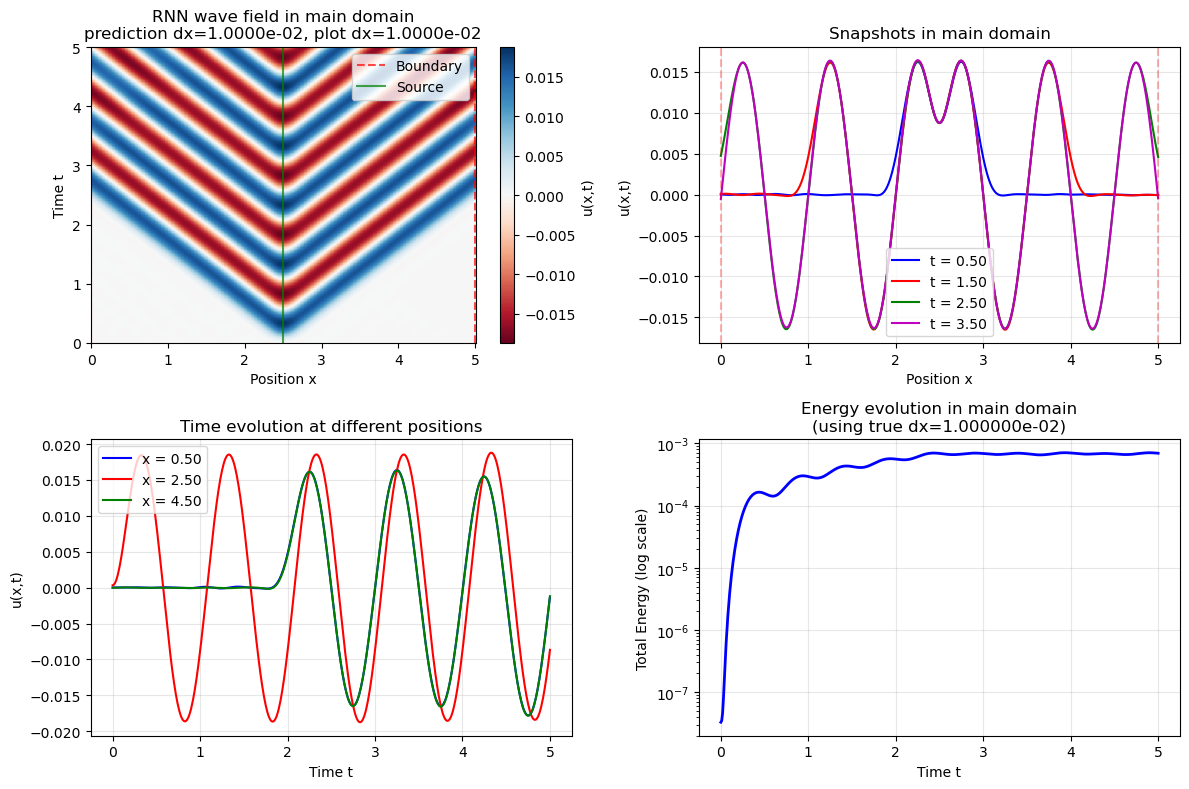

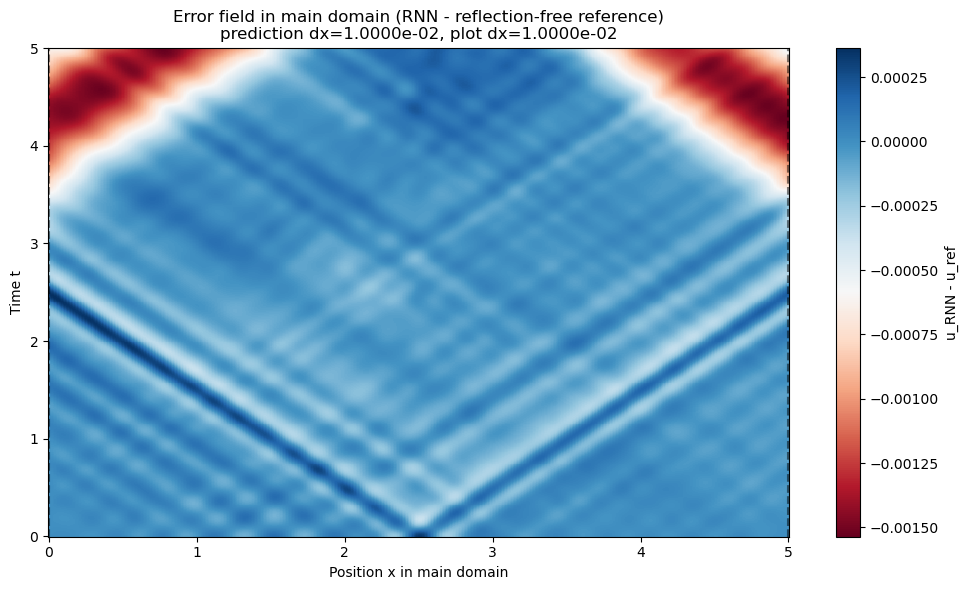

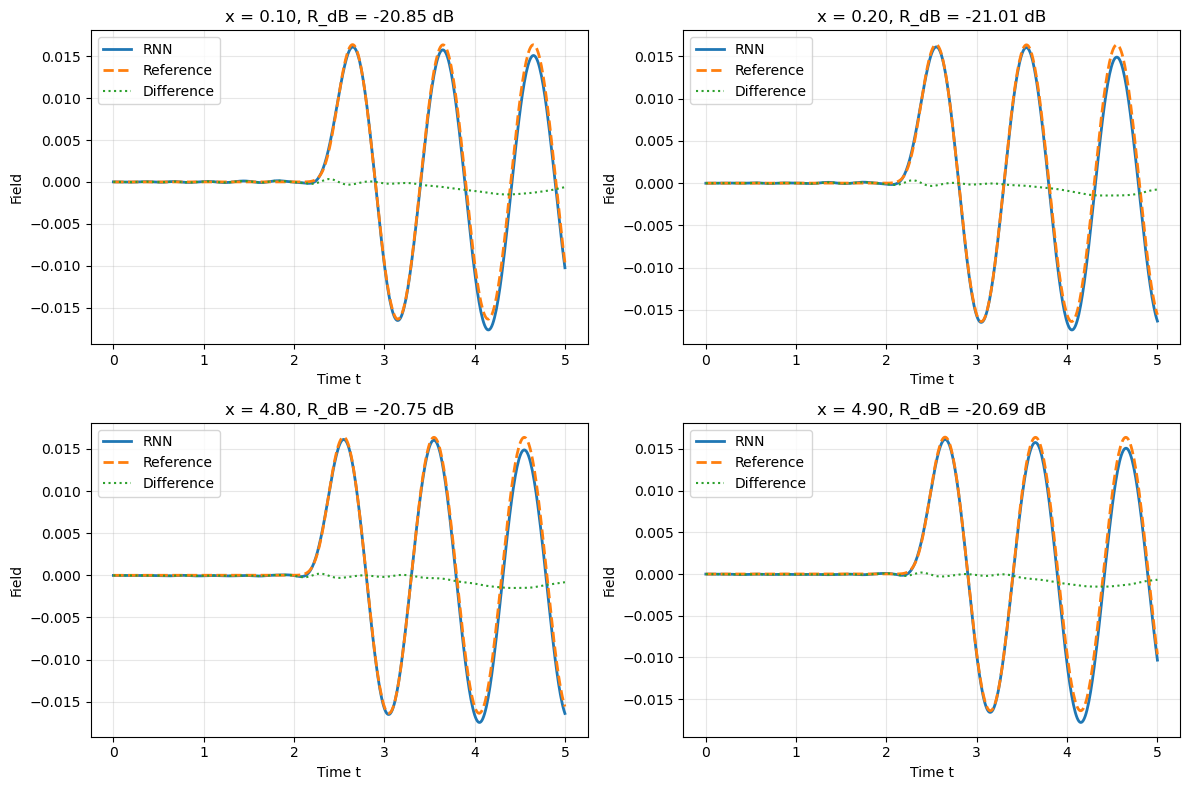

In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import time
from numba import njit

# ========== 1. Configuration & Setup ==========
initial_seed = 5
torch.manual_seed(initial_seed)
np.random.seed(initial_seed)

device = torch.device("cuda:4" if torch.cuda.is_available() else "cpu")
dtype = torch.double

# =========================
USE_PML = True

c = 1.0                 # Wave speed
L = 5.0                 # Physical domain [0, L]
T = 5.0                 # Total simulation time
num_neuron = 3000       # Number of neurons (Random Features)
r_neuron = [5, 5]       # Range for weight initialization

# ---------- Absorbing Boundary Settings (PML) ----------
pml_width = 1.5
sigma_max = 20.0
sigma_order = 3

# ---------- Source Settings ----------
x_src = L / 2.0
freq = 1.0

# ---------- Collocation Point Weights ----------
p_pde = 1.0
p_bnd = 10.0
p_ini_u = 10.0
p_ini_v = 10.0

# ---------- Training Point Counts ----------
N_pde = 30000
N_bnd = 20000
N_ini = 10000

# ---------- Reflection Coefficient Probe Positions ----------
probe_positions = [0.1, 0.2, 4.8, 4.9]

# ---------- Plotting Sampling Grid ----------
dx_plot = 0.01
dt_plot = dx_plot / c

# ---------- Reference Solution FDTD Parameters ----------
ref_dx = 1e-2
ref_CFL = 1.0
ref_sigma = 0.1
ref_omega = 2.0 * np.pi * freq

# ---------- Block-Solving Parameters ----------
solve_block_size = 5000       # Block size when assembling normal equations
predict_chunk_size_t = 20     # Chunk size for time-dimension during prediction

# ========== 2. Determine Computational Domain Based on Mode ==========
def get_domain_bounds(use_pml: bool):
    """
    Returns the computational domain bounds based on whether PML is used.
    With PML: domain extends beyond physical region.
    Without PML: domain is the physical region itself.
    """
    if use_pml:
        return -pml_width, L + pml_width
    else:
        return 0.0, L

x_left, x_right = get_domain_bounds(USE_PML)

# ========== 3. Print Grid Information ==========
def print_grid_info(name, dx_val, dt_val, Nx, Nt, x_min, x_max, t_min, t_max):
    """Prints detailed information about a given grid."""
    print("=" * 70)
    print(f"{name} Grid Information:")
    print(f"dx = {dx_val:.6f}, dt = {dt_val:.6f}")
    print(f"Spatial range: [{x_min:.2f}, {x_max:.2f}]")
    print(f"Time range: [{t_min:.2f}, {t_max:.2f}]")
    print(f"Spatial points (Nx): {Nx}")
    print(f"Time points (Nt): {Nt}")
    print(f"CFL number: {c * dt_val / dx_val:.6f}")
    print("=" * 70)

# ========== 4. Energy Calculation ==========
def compute_energy(u_field, dx):
    """
    Calculates the total energy in the domain at each time step.
    u_field: shape = (Nx, Nt)
    dx: Real spatial integration step size.
    """
    return np.sum(u_field ** 2, axis=0) * dx

# ========== 5. Activation Function and Derivatives ==========
def atv(x):
    """Hyperbolic tangent activation function."""
    return torch.tanh(x)

def diff1_atv(x):
    """First derivative of tanh."""
    return 1.0 - torch.tanh(x) ** 2

def diff2_atv(x):
    """Second derivative of tanh."""
    th = torch.tanh(x)
    return 2.0 * th * (th**2 - 1.0)

# ========== 6. Damping/Sigma Function for PML ==========
def sigma_x(X):
    """
    Calculates the damping coefficient sigma(x) for the PML.
    Only active if USE_PML is True.
    """
    X = X.to(dtype)
    sig = torch.zeros_like(X, dtype=dtype, device=X.device)

    if not USE_PML:
        return sig

    # Apply damping to left PML region
    left_mask = X < 0.0
    if left_mask.any():
        sig[left_mask] = sigma_max * ((0.0 - X[left_mask]) / pml_width) ** sigma_order

    # Apply damping to right PML region
    right_mask = X > L
    if right_mask.any():
        sig[right_mask] = sigma_max * ((X[right_mask] - L) / pml_width) ** sigma_order

    return sig

# ========== 7. Training Data Generation ==========
def generate_points():
    """
    Generates collocation points for PDE, boundary, and initial conditions.
    Uses a mix of uniform and Gaussian sampling for PDE points.
    """
    N_uniform = N_pde
    N_gaussian = N_pde - N_uniform

    # Uniform sampling for PDE points across the entire domain
    xi_uniform = x_left + (x_right - x_left) * torch.rand(
        N_uniform, 1, device=device, dtype=dtype
    )
    ti_uniform = T * torch.rand(
        N_uniform, 1, device=device, dtype=dtype
    )

    # Gaussian sampling around the source location for higher resolution
    xi_gaussian = torch.normal(
        mean=x_src,
        std=0.1,
        size=(N_gaussian, 1),
        device=device
    ).to(dtype).clamp(x_left, x_right)

    ti_gaussian = T * torch.rand(
        N_gaussian, 1, device=device, dtype=dtype
    )

    xi = torch.cat((xi_uniform, xi_gaussian), dim=0)
    ti = torch.cat((ti_uniform, ti_gaussian), dim=0)
    pti = torch.cat((xi, ti), dim=1).to(dtype)

    # Boundary points (on the extended domain if PML is used)
    tb = T * torch.rand(N_bnd, 1, device=device, dtype=dtype)
    ptb_left = torch.cat((torch.full_like(tb, x_left), tb), dim=1)
    ptb_right = torch.cat((torch.full_like(tb, x_right), tb), dim=1)
    ptb = torch.cat((ptb_left, ptb_right), dim=0).to(dtype)

    # Initial condition points (t=0)
    xi_ini = x_left + (x_right - x_left) * torch.rand(
        N_ini, 1, device=device, dtype=dtype
    )
    ti_ini = torch.zeros(N_ini, 1, device=device, dtype=dtype)
    pt_ini = torch.cat((xi_ini, ti_ini), dim=1).to(dtype)

    return pti, ptb, pt_ini

# ========== 8. Feature Value and Derivative Matrices ==========
def feature_value(W, b, points):
    """Computes the value of the basis function: tanh(W*X + b)."""
    points = points.to(W.dtype)
    b = b.to(W.dtype)

    X = points[:, 0:1]
    Tt = points[:, 1:2]
    W_x = W[0:1, :]
    W_t = W[1:2, :]

    Z = X @ W_x + Tt @ W_t + b
    return atv(Z)

def feature_t(W, b, points):
    """Computes the time derivative of the basis function."""
    points = points.to(W.dtype)
    b = b.to(W.dtype)

    X = points[:, 0:1]
    Tt = points[:, 1:2]
    W_x = W[0:1, :]
    W_t = W[1:2, :]

    Z = X @ W_x + Tt @ W_t + b
    return W_t * diff1_atv(Z)

def feature_xx(W, b, points):
    """Computes the second spatial derivative of the basis function."""
    points = points.to(W.dtype)
    b = b.to(W.dtype)

    X = points[:, 0:1]
    Tt = points[:, 1:2]
    W_x = W[0:1, :]
    W_t = W[1:2, :]

    Z = X @ W_x + Tt @ W_t + b
    return (W_x ** 2) * diff2_atv(Z)

def feature_tt(W, b, points):
    """Computes the second time derivative of the basis function."""
    points = points.to(W.dtype)
    b = b.to(W.dtype)

    X = points[:, 0:1]
    Tt = points[:, 1:2]
    W_x = W[0:1, :]
    W_t = W[1:2, :]

    Z = X @ W_x + Tt @ W_t + b
    return (W_t ** 2) * diff2_atv(Z)

# ========== 9. Source Term ==========
def source_term(points):
    """
    Defines the source term: cos(2*pi*f*t) * exp(-(x-x_src)^2 / 0.02).
    """
    points = points.to(dtype)
    X = points[:, 0:1]
    Tt = points[:, 1:2]
    return torch.cos(2.0 * np.pi * freq * Tt) * torch.exp(-((X - x_src) ** 2) / 0.02)

# ========== 10. Initial Conditions ==========
def u0(x):
    """Initial displacement: u(x, 0) = 0."""
    x = x.to(dtype)
    return torch.zeros_like(x)

def v0(x):
    """Initial velocity: du/dt(x, 0) = 0."""
    x = x.to(dtype)
    return torch.zeros_like(x)

# ========== 11. PDE Residual Matrix (Core Operator) ==========
def wave_equation_residual(W, b, points, c):
    """
    Computes the residual of the wave equation.
    If PML is enabled, adds the damping term sigma*u_t.
    """
    points = points.to(W.dtype)
    phi_tt = feature_tt(W, b, points)
    phi_xx = feature_xx(W, b, points)

    if USE_PML:
        X = points[:, 0:1]
        sig = sigma_x(X).to(W.dtype)
        phi_t = feature_t(W, b, points)
        return phi_tt + sig * phi_t - (c ** 2) * phi_xx
    else:
        return phi_tt - (c ** 2) * phi_xx

# ========== 12. Utility Functions for Comparison ==========
def interpolate_trace_along_x(x_grid, u_xt, x_query):
    """
    Interpolates the field u(x,t) at a specific x_query over all times.
    """
    if x_query <= x_grid[0]:
        return u_xt[0, :].copy()
    if x_query >= x_grid[-1]:
        return u_xt[-1, :].copy()

    i1 = np.searchsorted(x_grid, x_query)
    i0 = i1 - 1
    x0 = x_grid[i0]
    x1 = x_grid[i1]
    alpha = (x_query - x0) / (x1 - x0)
    return (1.0 - alpha) * u_xt[i0, :] + alpha * u_xt[i1, :]

def interpolate_trace_in_time(t_old, trace_old, t_new):
    """
    Interpolates a time trace from an old time grid to a new one.
    """
    return np.interp(t_new, t_old, trace_old)

def compute_reflection_metrics(
    x_num, t_num, u_num_xt,
    x_ref, t_ref, u_ref_xt,
    probe_positions,
    eps=1e-15
):
    """
    Compares numerical solution against a reference solution at specified probe points.
    Calculates reflection coefficients.
    """
    results = []

    for xpos in probe_positions:
        trace_num = interpolate_trace_along_x(x_num, u_num_xt, xpos)
        trace_ref_raw = interpolate_trace_along_x(x_ref, u_ref_xt, xpos)

        # Interpolate reference trace to match numerical solution's time grid if needed
        if len(t_ref) != len(t_num) or not np.allclose(t_ref, t_num):
            trace_ref = interpolate_trace_in_time(t_ref, trace_ref_raw, t_num)
        else:
            trace_ref = trace_ref_raw

        diff_trace = trace_num - trace_ref
        numerator = np.max(np.abs(diff_trace))
        denominator = np.max(np.abs(trace_ref))

        if denominator < eps:
            R = np.nan
            R_dB = np.nan
        else:
            R = numerator / denominator
            R_dB = 20.0 * np.log10(max(R, eps))

        results.append({
            'x': xpos,
            'R_linear': R,
            'R_dB': R_dB,
            'trace_num': trace_num,
            'trace_ref': trace_ref,
            'trace_diff': diff_trace
        })

    return results

def compute_worst_reflection_in_region(
    x_num, t_num, u_num_xt,
    x_ref, t_ref, u_ref_xt,
    x_region_min, x_region_max,
    n_probe=50,
    eps=1e-15
):
    """
    Finds the point with the highest reflection coefficient within a specified region.
    """
    probe_x = np.linspace(x_region_min, x_region_max, n_probe)
    results = compute_reflection_metrics(
        x_num, t_num, u_num_xt,
        x_ref, t_ref, u_ref_xt,
        probe_x, eps=eps
    )
    valid = [r for r in results if np.isfinite(r['R_linear'])]
    if len(valid) == 0:
        return None
    return max(valid, key=lambda d: d['R_linear'])

# ========== 13. Reference Solution Generation (FDTD) ==========
def build_reference_problem(
    c, L_phys, T_total, dx, CFL, x_src_phys, sigma, omega,
    n_save_t=None, n_save_x=None
):
    """
    Sets up parameters for the FDTD reference solver.
    Creates an extended domain with PML-like absorbing layers.
    """
    dt = CFL * dx / c
    nt = int(np.ceil(T_total / dt))
    dt = T_total / nt
    cfl_actual = c * dt / dx
    if cfl_actual > 1.0 + 1e-12:
        raise ValueError(f"CFL violated in reference solver: {cfl_actual:.6f}")

    if n_save_t is None:
        n_save_t = nt + 1
    if n_save_x is None:
        n_save_x = int(round(L_phys / dx)) + 1

    # Calculate necessary guard width to prevent reflections from boundaries
    min_guard = max(0.0, c * T_total - L_phys / 2.0)
    safety_margin = max(6.0 * sigma, 20.0 * dx, 0.5)
    guard_width = min_guard + safety_margin

    L_ext = L_phys + 2.0 * guard_width
    nx_ext = int(round(L_ext / dx)) + 1
    x_ext = np.linspace(0.0, L_ext, nx_ext)

    x_phys_left = guard_width
    x_src_ext = x_phys_left + x_src_phys

    # Gaussian source profile on the extended grid
    gaussian_source_weights = np.exp(-(x_ext - x_src_ext) ** 2 / (2.0 * sigma ** 2))

    x_save_phys = np.linspace(0.0, L_phys, n_save_x)
    save_t_idx = np.arange(n_save_t, dtype=np.int64)

    return {
        'dt': dt,
        'nt': nt,
        'nx_ext': nx_ext,
        'x_phys_left': x_phys_left,
        'gaussian_source_weights': gaussian_source_weights,
        'x_save_phys': x_save_phys,
        'save_t_idx': save_t_idx
    }

@njit
def fdtd_1d_reference_main_only(
    c, dx, dt, nt, nx_ext,
    omega, gaussian_source_weights,
    x_phys_left, x_save_phys, save_t_idx
):
    """
    Fast FDTD solver implemented with Numba for efficiency.
    Solves on an extended grid and saves only the physical domain.
    """
    coef = (c * dt / dx) ** 2

    E_prev = np.zeros(nx_ext)
    E_current = np.zeros(nx_ext)
    E_next = np.zeros(nx_ext)

    n_save_t = save_t_idx.shape[0]
    n_save_x = x_save_phys.shape[0]
    E_save_phys = np.zeros((n_save_t, n_save_x))

    save_counter = 0

    for n in range(nt + 1):
        t_now = n * dt

        # Update interior points
        for i in range(1, nx_ext - 1):
            E_next[i] = (
                2.0 * E_current[i]
                - E_prev[i]
                + coef * (E_current[i + 1] - 2.0 * E_current[i] + E_current[i - 1])
            )
        
        # Apply source term
        amplitude = 0.5 if n < 1 else 1.0 
        source_factor = amplitude * (dt ** 2) * np.cos(omega * t_now)
        for i in range(nx_ext):
            E_next[i] += gaussian_source_weights[i] * source_factor

        # Apply Dirichlet boundary conditions (hard walls)
        E_next[0] = 0.0
        E_next[nx_ext - 1] = 0.0

        # Save solution for physical domain only
        if save_counter < n_save_t and n == save_t_idx[save_counter]:
            for j in range(n_save_x):
                x_abs = x_phys_left + x_save_phys[j]
                cell = x_abs / dx
                i0 = int(np.floor(cell))

                if i0 < 0:
                    i0 = 0
                if i0 >= nx_ext - 1:
                    i0 = nx_ext - 2

                alpha = cell - i0
                E_save_phys[save_counter, j] = (
                    (1.0 - alpha) * E_current[i0] + alpha * E_current[i0 + 1]
                )
            save_counter += 1

        # Swap arrays for next time step
        tmp = E_prev
        E_prev = E_current
        E_current = E_next
        E_next = tmp

        for i in range(nx_ext):
            E_next[i] = 0.0

    return E_save_phys

def generate_reference_solution():
    """
    Generates the reference solution using the FDTD method.
    """
    ref_cfg = build_reference_problem(
        c=c,
        L_phys=L,
        T_total=T,
        dx=ref_dx,
        CFL=ref_CFL,
        x_src_phys=x_src,
        sigma=ref_sigma,
        omega=ref_omega,
        n_save_t=None,
        n_save_x=None
    )

    # Warm-up run for Numba
    _ = fdtd_1d_reference_main_only(
        c, ref_dx, ref_cfg['dt'], 1, ref_cfg['nx_ext'],
        ref_omega, ref_cfg['gaussian_source_weights'],
        ref_cfg['x_phys_left'], ref_cfg['x_save_phys'],
        np.array([0, 1], dtype=np.int64)
    )

    start = time.perf_counter()
    E_save_phys = fdtd_1d_reference_main_only(
        c, ref_dx, ref_cfg['dt'], ref_cfg['nt'], ref_cfg['nx_ext'],
        ref_omega, ref_cfg['gaussian_source_weights'],
        ref_cfg['x_phys_left'], ref_cfg['x_save_phys'],
        ref_cfg['save_t_idx']
    )
    elapsed = time.perf_counter() - start

    x_ref = ref_cfg['x_save_phys']
    t_ref = ref_cfg['save_t_idx'] * ref_cfg['dt']
    u_ref_xt = E_save_phys.T  # Transpose to (Nx, Nt)

    print(f"Reference solution generated in {elapsed:.3f} s")
    return x_ref, t_ref, u_ref_xt

# ========== 14. Block-Wise Normal Equation Solver ==========
@torch.no_grad()
def solve_blockwise_normal_equation(W, b, pti, ptb, pt_ini, c, block_size=4000, ridge=1e-6):
    """
    Solves the normal equation A^T A Ur = A^T F in blocks to avoid memory overflow.
    The PDE part is accumulated in blocks, while boundary/initial parts are accumulated once.
    """
    M = W.shape[1]
    ATA = torch.zeros((M, M), dtype=dtype, device=device)
    ATF = torch.zeros((M, 1), dtype=dtype, device=device)

    n_pde_total = pti.shape[0]

    start_solve = time.perf_counter()

    # -------------------------------------------------
    # 1) Accumulate PDE contributions in blocks
    # -------------------------------------------------
    for i0 in range(0, n_pde_total, block_size):
        i1 = min(i0 + block_size, n_pde_total)
        pti_block = pti[i0:i1]

        A_pde_block = p_pde * wave_equation_residual(W, b, pti_block, c)
        F_pde_block = p_pde * source_term(pti_block).to(dtype)

        ATA += A_pde_block.T @ A_pde_block
        ATF += A_pde_block.T @ F_pde_block

        # Free memory after processing each block
        del pti_block, A_pde_block, F_pde_block
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    # -------------------------------------------------
    # 2) Accumulate boundary condition contribution once
    # -------------------------------------------------
    A_bnd = p_bnd * feature_value(W, b, ptb)
    F_bnd = torch.zeros((ptb.shape[0], 1), dtype=dtype, device=device)

    ATA += A_bnd.T @ A_bnd
    ATF += A_bnd.T @ F_bnd

    del A_bnd, F_bnd
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # -------------------------------------------------
    # 3) Accumulate initial displacement contribution once
    # -------------------------------------------------
    A_ini_u = p_ini_u * feature_value(W, b, pt_ini)
    F_ini_u = p_ini_u * u0(pt_ini[:, 0:1]).to(dtype)

    ATA += A_ini_u.T @ A_ini_u
    ATF += A_ini_u.T @ F_ini_u

    del A_ini_u, F_ini_u
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # -------------------------------------------------
    # 4) Accumulate initial velocity contribution once
    # -------------------------------------------------
    A_ini_v = p_ini_v * feature_t(W, b, pt_ini)
    F_ini_v = p_ini_v * v0(pt_ini[:, 0:1]).to(dtype)

    ATA += A_ini_v.T @ A_ini_v
    ATF += A_ini_v.T @ F_ini_v

    del A_ini_v, F_ini_v
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # -------------------------------------------------
    # 5) Regularize and solve the final system
    # -------------------------------------------------
    ATA += ridge * torch.eye(M, dtype=dtype, device=device)
    Ur = torch.linalg.solve(ATA, ATF)

    elapsed = time.perf_counter() - start_solve
    print(f"Blockwise normal-equation solve finished in {elapsed:.3f} s")

    return Ur

# ========== 15. Batched Prediction ==========
@torch.no_grad()
def predict_main_grid_in_batches(x_test, t_test, W, b, Ur, chunk_size_t=20):
    """
    Performs prediction on the main domain grid in time chunks to manage memory.
    Returns a numpy array of shape (Nx, Nt).
    """
    Nx = x_test.shape[0]
    Nt = t_test.shape[0]

    u_pred_np = np.zeros((Nx, Nt), dtype=np.float64)

    W_x = W[0:1, :]   # (1, M)
    W_t = W[1:2, :]   # (1, M)

    # Pre-compute the spatial part of the feature map
    X_part = x_test.unsqueeze(1) @ W_x  # (Nx, M)

    pred_start = time.perf_counter()

    for j0 in range(0, Nt, chunk_size_t):
        j1 = min(j0 + chunk_size_t, Nt)
        t_chunk = t_test[j0:j1]

        # Compute the time part of the feature map for this chunk
        T_part = t_chunk.unsqueeze(1) @ W_t                 # (chunk, M)
        # Broadcast spatial and temporal parts together
        Z_chunk = X_part[:, None, :] + T_part[None, :, :] + b[None, :, :]
        phi_chunk = atv(Z_chunk)

        # Reshape for batched matrix multiplication with Ur
        phi_2d = phi_chunk.reshape(-1, phi_chunk.shape[-1])  # (Nx*chunk, M)
        u_chunk = (phi_2d @ Ur).reshape(Nx, j1 - j0)

        u_pred_np[:, j0:j1] = u_chunk.detach().cpu().numpy()

        # Clean up temporary variables
        del t_chunk, T_part, Z_chunk, phi_chunk, phi_2d, u_chunk
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    elapsed = time.perf_counter() - pred_start
    print(f"Batched prediction finished in {elapsed:.3f} s")

    return u_pred_np

# ========== 16. Build Plotting Indices ==========
def build_plot_indices_from_physical_step(x_grid, t_grid, dx_target, dt_target):
    """
    Selects uniform indices from existing grids based on desired physical step sizes.
    This allows for coarser plotting without regenerating the full solution.
    """
    x_min, x_max = x_grid[0], x_grid[-1]
    t_min, t_max = t_grid[0], t_grid[-1]

    # Calculate desired number of points
    Nx_plot = int(round((x_max - x_min) / dx_target)) + 1
    Nt_plot = int(round((t_max - t_min) / dt_target)) + 1

    # Find the closest indices in the original grid
    x_plot_target = np.linspace(x_min, x_max, Nx_plot)
    t_plot_target = np.linspace(t_min, t_max, Nt_plot)

    x_idx = np.searchsorted(x_grid, x_plot_target)
    x_idx = np.clip(x_idx, 0, len(x_grid) - 1)

    t_idx = np.searchsorted(t_grid, t_plot_target)
    t_idx = np.clip(t_idx, 0, len(t_grid) - 1)

    # Remove duplicates caused by rounding
    x_idx = np.unique(x_idx)
    t_idx = np.unique(t_idx)

    return x_idx, t_idx

# ========== 17. Main Execution ==========
# ---- Initialize Random Feature Parameters ----
W1 = torch.tensor(
    np.random.uniform(-r_neuron[0], r_neuron[0], (1, num_neuron)),
    dtype=dtype,
    device=device
)
W2 = torch.tensor(
    np.random.uniform(-r_neuron[1], r_neuron[1], (1, num_neuron)),
    dtype=dtype,
    device=device
)
W = torch.cat((W1, W2), dim=0)

# Initialize biases and apply bias correction
b1 = torch.tensor(
    np.random.uniform(x_left, x_right, (1, num_neuron)),
    dtype=dtype,
    device=device
)
b2 = torch.tensor(
    np.random.uniform(0.0, T, (1, num_neuron)),
    dtype=dtype,
    device=device
)
b_shift = torch.cat((b1, b2), dim=0)
b = -torch.sum(b_shift * W, dim=0, keepdim=True)

# ---- Generate Training Points ----
pti, ptb, pt_ini = generate_points()

pti = pti.to(dtype)
ptb = ptb.to(dtype)
pt_ini = pt_ini.to(dtype)
W = W.to(dtype)
b = b.to(dtype)

print(f"USE_PML: {USE_PML}")
print(f"Domain: [{x_left}, {x_right}]")
print(f"Device: {device}")

# ========== Generate Reference Solution First ==========
x_ref, t_ref, u_ref_xt = generate_reference_solution()
# Optionally load a pre-saved reference instead
# u_ref_xt = np.load('1d_fdtd_ref_5e-5.npy').T

dx_pred = x_ref[1] - x_ref[0]
dt_pred = t_ref[1] - t_ref[0]
Nx_pred = len(x_ref)
Nt_pred = len(t_ref)

print_grid_info(
    name="Prediction / Reference",
    dx_val=dx_pred,
    dt_val=dt_pred,
    Nx=Nx_pred,
    Nt=Nt_pred,
    x_min=x_ref[0],
    x_max=x_ref[-1],
    t_min=t_ref[0],
    t_max=t_ref[-1]
)

total_start_time = time.time()

# ========== Solve in Blocks ==========
Ur = solve_blockwise_normal_equation(
    W=W,
    b=b,
    pti=pti,
    ptb=ptb,
    pt_ini=pt_ini,
    c=c,
    block_size=solve_block_size,
    ridge=1e-6
)

# ========== Predict RNN Solution on Reference Grid ==========
x_test_main = torch.tensor(x_ref, device=device, dtype=dtype)
t_test_main = torch.tensor(t_ref, device=device, dtype=dtype)

u_pred_main = predict_main_grid_in_batches(
    x_test=x_test_main,
    t_test=t_test_main,
    W=W,
    b=b,
    Ur=Ur,
    chunk_size_t=predict_chunk_size_t
)

print("Prediction Finished")
total_end_time = time.time()
print(f"\nTotal wall-clock time: {total_end_time - total_start_time:.3f} s")

# ========== Compare with Reference Solution ==========
rel_err = np.linalg.norm(u_pred_main - u_ref_xt) / max(np.linalg.norm(u_ref_xt), 1e-15)
print(f"Relative L2 Error (main domain, vs reflection-free reference): {rel_err:.2%}")

error_main = u_pred_main - u_ref_xt

# Calculate reflection metrics
reflection_results = compute_reflection_metrics(
    x_num=x_ref,
    t_num=t_ref,
    u_num_xt=u_pred_main,
    x_ref=x_ref,
    t_ref=t_ref,
    u_ref_xt=u_ref_xt,
    probe_positions=probe_positions
)

print("\n===== Reflection Coefficients at Probe Points =====")
for item in reflection_results:
    print(
        f"x = {item['x']:.2f} : "
        f"R = {item['R_linear']:.6e}, "
        f"R_dB = {item['R_dB']:.2f} dB"
    )

print("\n===== Summary Table =====")
print(f"{'Probe x':>10s} | {'R (linear)':>14s} | {'R (dB)':>10s}")
print("-" * 42)
for item in reflection_results:
    print(f"{item['x']:10.2f} | {item['R_linear']:14.6e} | {item['R_dB']:10.2f}")

# Find worst reflection on left and right sides
left_worst = compute_worst_reflection_in_region(
    x_ref, t_ref, u_pred_main,
    x_ref, t_ref, u_ref_xt,
    0.0, 0.5, n_probe=50
)
right_worst = compute_worst_reflection_in_region(
    x_ref, t_ref, u_pred_main,
    x_ref, t_ref, u_ref_xt,
    4.5, 5.0, n_probe=50
)

if left_worst is not None:
    print(f"\nWorst reflection on left side [0.0, 0.5]: x = {left_worst['x']:.4f}, "
          f"R = {left_worst['R_linear']:.6e}, R_dB = {left_worst['R_dB']:.2f} dB")
if right_worst is not None:
    print(f"Worst reflection on right side [4.5, 5.0]: x = {right_worst['x']:.4f}, "
          f"R = {right_worst['R_linear']:.6e}, R_dB = {right_worst['R_dB']:.2f} dB")

# ========== Prepare Data for Plotting ==========
x_idx_plot, t_idx_plot = build_plot_indices_from_physical_step(
    x_grid=x_ref,
    t_grid=t_ref,
    dx_target=dx_plot,
    dt_target=dt_plot
)

x_plot = x_ref[x_idx_plot]
t_plot = t_ref[t_idx_plot]

u_plot = u_pred_main[np.ix_(x_idx_plot, t_idx_plot)]
u_plot_xt = u_plot.T

u_ref_plot = u_ref_xt[np.ix_(x_idx_plot, t_idx_plot)]
error_plot = error_main[np.ix_(x_idx_plot, t_idx_plot)]

actual_dx_plot = x_plot[1] - x_plot[0] if len(x_plot) > 1 else np.nan
actual_dt_plot = t_plot[1] - t_plot[0] if len(t_plot) > 1 else np.nan

print_grid_info(
    name="Plot",
    dx_val=actual_dx_plot,
    dt_val=actual_dt_plot,
    Nx=len(x_plot),
    Nt=len(t_plot),
    x_min=x_plot[0],
    x_max=x_plot[-1],
    t_min=t_plot[0],
    t_max=t_plot[-1]
)

# ========== Calculate Energy (using real prediction grid dx_pred) ==========
energy = compute_energy(u_pred_main, dx_pred)

# ========== Visualization ==========
plt.figure(figsize=(12, 8))

# ---- Subplot 1: RNN Spacetime Field ----
plt.subplot(2, 2, 1)
plt.pcolormesh(x_plot, t_plot, u_plot_xt, shading='auto', cmap='RdBu')
plt.colorbar(label='u(x,t)')
plt.xlabel('Position x')
plt.ylabel('Time t')
plt.title(
    f'RNN wave field in main domain\n'
    f'prediction dx={dx_pred:.4e}, plot dx={actual_dx_plot:.4e}'
)
plt.axvline(x=0.0, color='r', linestyle='--', alpha=0.7, label='Boundary')
plt.axvline(x=L, color='r', linestyle='--', alpha=0.7)
plt.axvline(x=x_src, color='g', linestyle='-', alpha=0.7, label='Source')
plt.legend()

# ---- Subplot 2: Cross-sections at specific times ----
plt.subplot(2, 2, 2)
time_indices = [
    int(0.1 * len(t_plot)),
    int(0.3 * len(t_plot)),
    int(0.5 * len(t_plot)),
    int(0.7 * len(t_plot))
]
colors = ['b', 'r', 'g', 'm']
for i, tidx in enumerate(time_indices):
    plt.plot(x_plot, u_plot_xt[tidx, :], color=colors[i], label=f't = {t_plot[tidx]:.2f}')
plt.xlabel('Position x')
plt.ylabel('u(x,t)')
plt.title('Snapshots in main domain')
plt.axvline(x=0.0, color='r', linestyle='--', alpha=0.3)
plt.axvline(x=L, color='r', linestyle='--', alpha=0.3)
plt.grid(True, alpha=0.3)
plt.legend()

# ---- Subplot 3: Time evolution at specific positions ----
plt.subplot(2, 2, 3)
position_list = [0.5, 2.5, 4.5]
for i, xpos in enumerate(position_list):
    x_idx = np.argmin(np.abs(x_ref - xpos))
    plt.plot(t_ref, u_pred_main[x_idx, :], color=colors[i], label=f'x = {x_ref[x_idx]:.2f}')
plt.xlabel('Time t')
plt.ylabel('u(x,t)')
plt.title('Time evolution at different positions')
plt.grid(True, alpha=0.3)
plt.legend()

# ---- Subplot 4: Total Energy Evolution ----
plt.subplot(2, 2, 4)
plt.semilogy(t_ref, energy, 'b-', linewidth=2)
plt.xlabel('Time t')
plt.ylabel('Total Energy (log scale)')
plt.title(f'Energy evolution in main domain\n(using true dx={dx_pred:.6e})')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ========== Main Domain Error Spacetime Plot ==========
plt.figure(figsize=(10, 6))
plt.pcolormesh(x_plot, t_plot, error_plot.T, shading='auto', cmap='RdBu')
plt.colorbar(label='u_RNN - u_ref')
plt.xlabel('Position x in main domain')
plt.ylabel('Time t')
plt.title(
    f'Error field in main domain (RNN - reflection-free reference)\n'
    f'prediction dx={dx_pred:.4e}, plot dx={actual_dx_plot:.4e}'
)
plt.axvline(x=0.0, color='k', linestyle='--', alpha=0.5)
plt.axvline(x=L, color='k', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ========== Time Series Comparison at Probe Points ==========
plt.figure(figsize=(12, 8))
for k, item in enumerate(reflection_results):
    plt.subplot(2, 2, k + 1)
    plt.plot(t_ref, item['trace_num'], label='RNN', linewidth=2)
    plt.plot(t_ref, item['trace_ref'], '--', label='Reference', linewidth=2)
    plt.plot(t_ref, item['trace_diff'], ':', label='Difference', linewidth=1.5)
    plt.xlabel('Time t')
    plt.ylabel('Field')
    plt.title(f"x = {item['x']:.2f}, R_dB = {item['R_dB']:.2f} dB")
    plt.grid(True, alpha=0.3)
    plt.legend()

plt.tight_layout()
plt.show()

# Seed Sensitivity Test for the 1D RNN with Damping Absorbing Layers

Device: cuda:4
USE_PML: True
Domain: [-1.5, 6.5]
RUN_SEED_STUDY: True
Reference solution generated in 0.002 s
Prediction / Reference Grid Information:
dx = 0.010000, dt = 0.010000
Spatial range: [0.00, 5.00]
Time range: [0.00, 5.00]
Spatial points (Nx): 501
Time points (Nt): 501
CFL number: 1.000000

Running seed study mode = both

----------------------------------------------------------------------
mode=both, model_seed=0, point_seed=10000
----------------------------------------------------------------------
Blockwise normal-equation solve finished in 0.790 s
Batched prediction finished in 0.081 s

----------------------------------------------------------------------
mode=both, model_seed=1, point_seed=10001
----------------------------------------------------------------------
Blockwise normal-equation solve finished in 0.192 s
Batched prediction finished in 0.082 s

----------------------------------------------------------------------
mode=both, model_seed=2, point_seed=10002
-

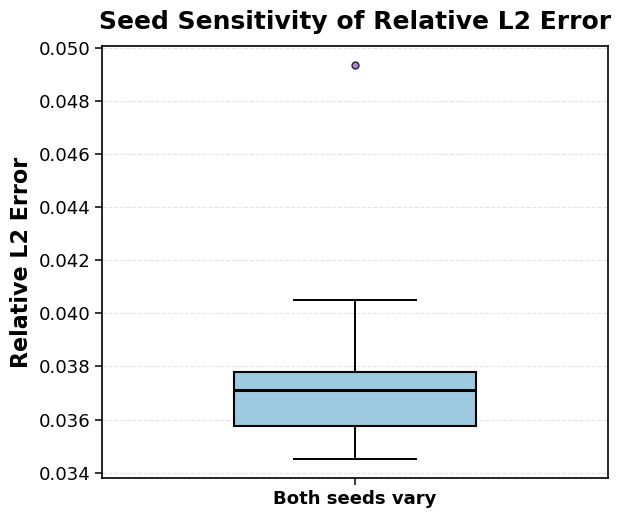

Saved: paper_figures_seed_study/fig_main_probe_errorbar_both.png
Saved: paper_figures_seed_study/fig_main_probe_errorbar_both.pdf


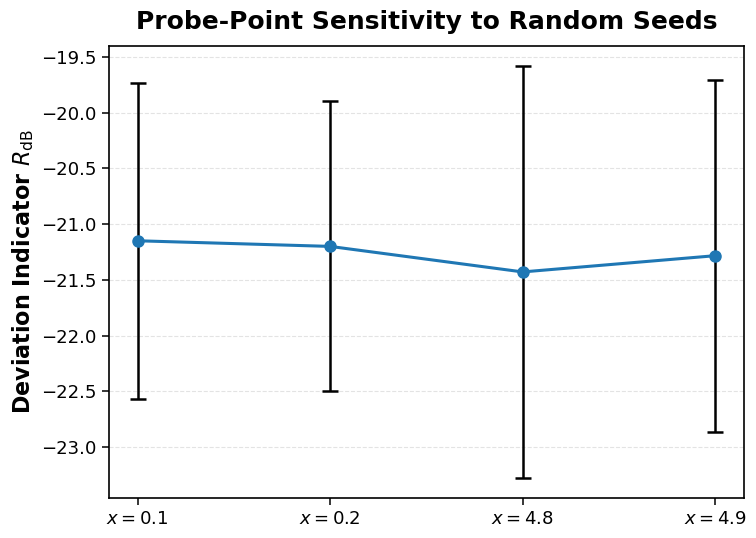

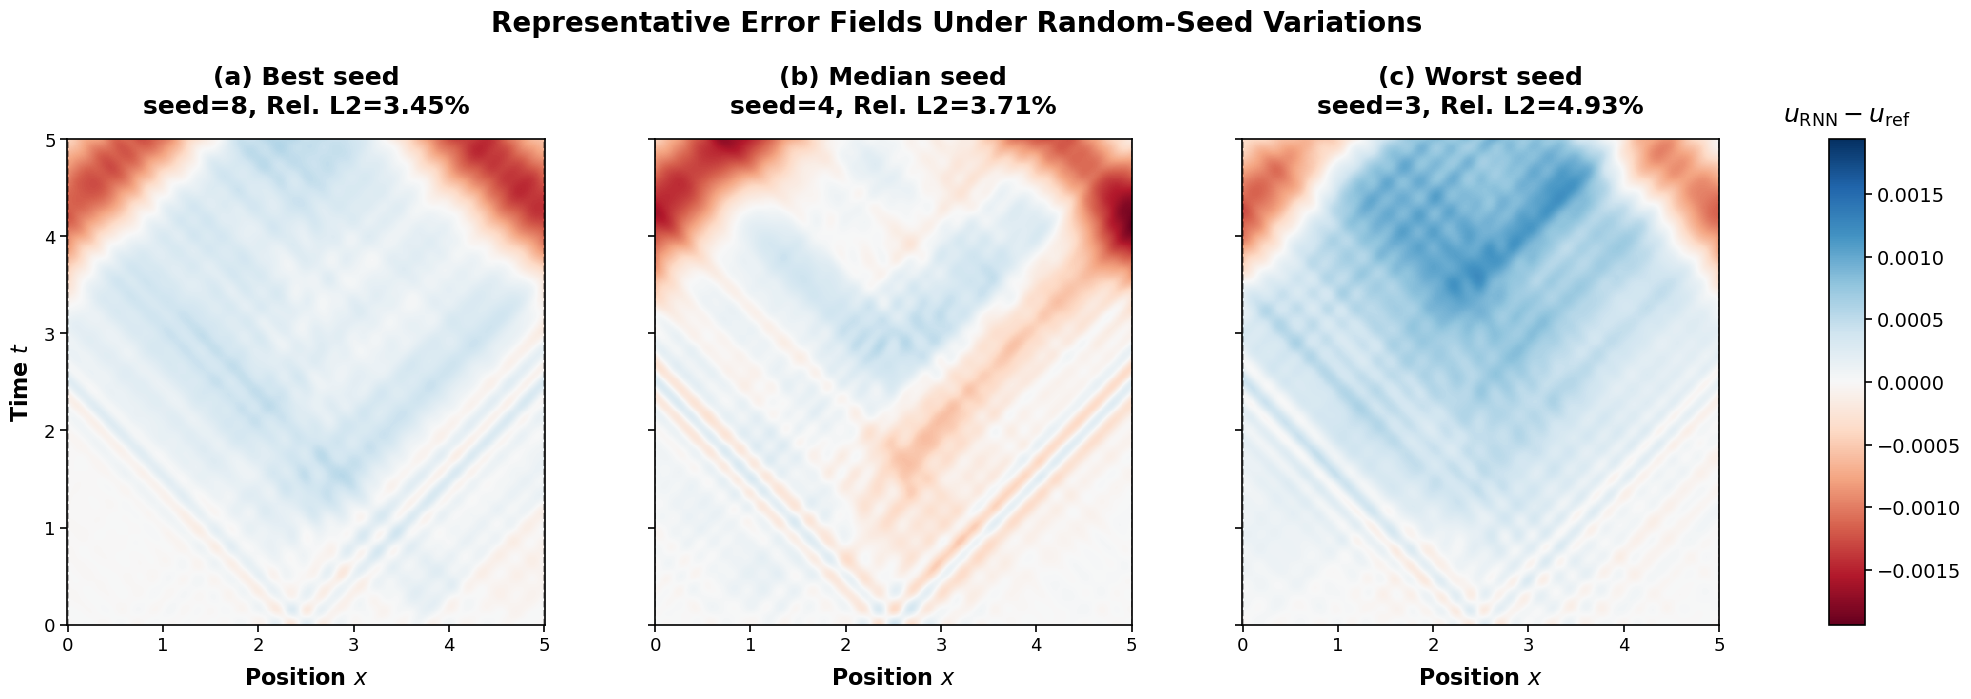

/tmp/ipykernel_1337549/2262259520.py:1215: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


Saved: paper_figures_seed_study/fig_appendix_rel_l2_three_modes.png
Saved: paper_figures_seed_study/fig_appendix_rel_l2_three_modes.pdf


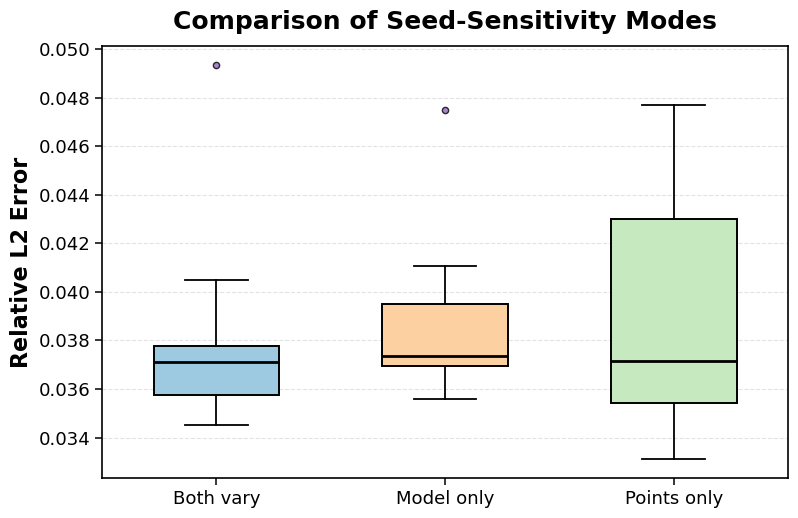

/tmp/ipykernel_1337549/2262259520.py:1251: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


Saved: paper_figures_seed_study/fig_appendix_probe_boxplot_both_vary.png
Saved: paper_figures_seed_study/fig_appendix_probe_boxplot_both_vary.pdf


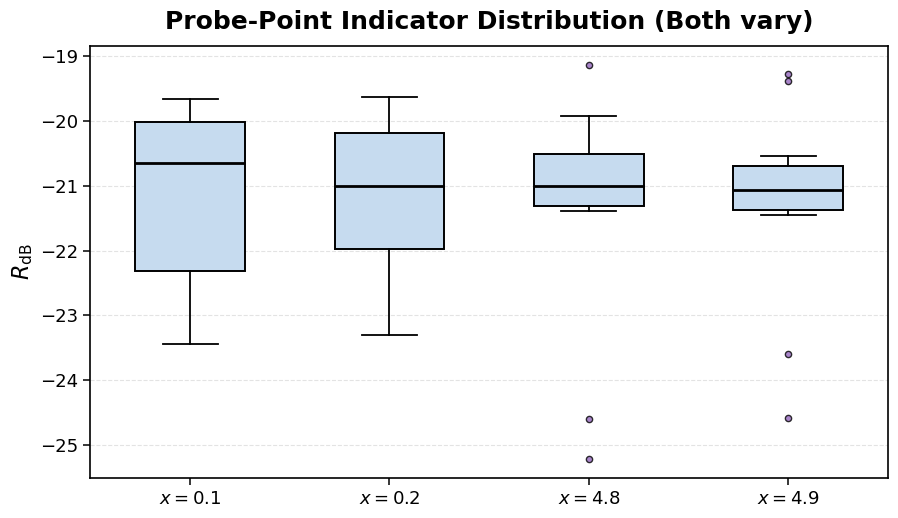

/tmp/ipykernel_1337549/2262259520.py:1251: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


Saved: paper_figures_seed_study/fig_appendix_probe_boxplot_model_only.png
Saved: paper_figures_seed_study/fig_appendix_probe_boxplot_model_only.pdf


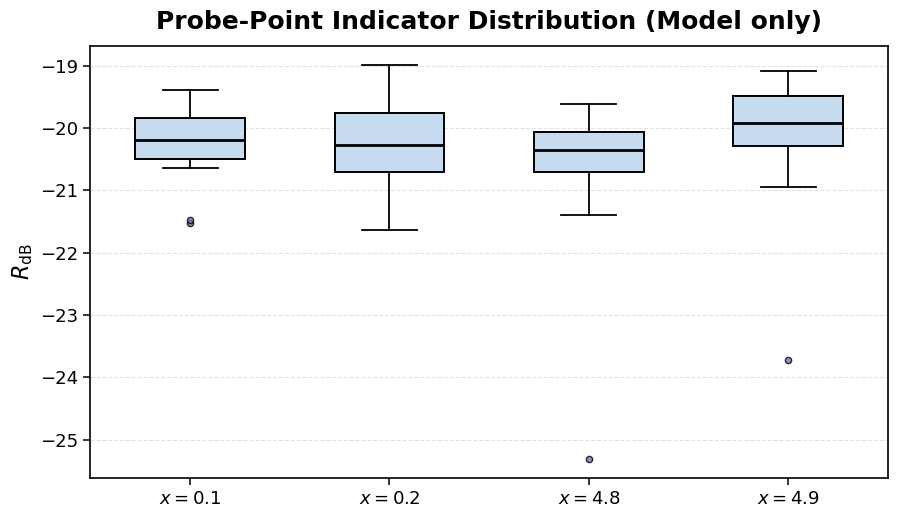

/tmp/ipykernel_1337549/2262259520.py:1251: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


Saved: paper_figures_seed_study/fig_appendix_probe_boxplot_points_only.png
Saved: paper_figures_seed_study/fig_appendix_probe_boxplot_points_only.pdf


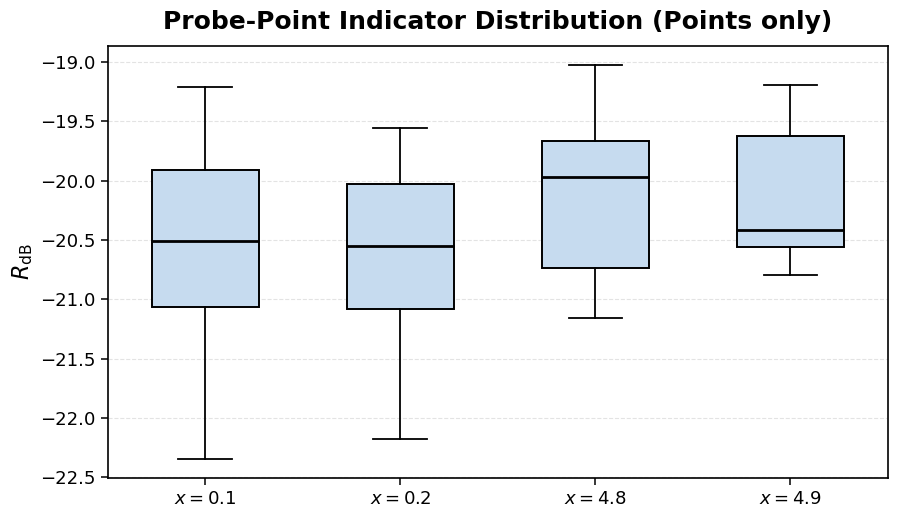

/tmp/ipykernel_1337549/2262259520.py:1279: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


Saved: paper_figures_seed_study/fig_appendix_worst_boundary_both.png
Saved: paper_figures_seed_study/fig_appendix_worst_boundary_both.pdf


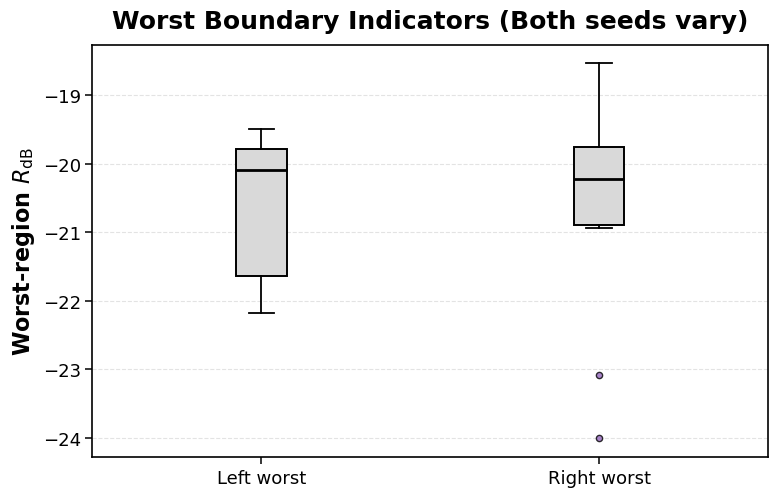

Saved: paper_figures_seed_study/seed_sensitivity_detailed_table.csv

All figures and tables have been saved to:
paper_figures_seed_study


In [1]:
import os
import time
import numpy as np
import pandas as pd
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
from numba import njit

# ============================================================
# 1. Global Configuration
# ============================================================
initial_seed = 5
torch.manual_seed(initial_seed)
np.random.seed(initial_seed)

device = torch.device("cuda:4" if torch.cuda.is_available() else "cpu")
dtype = torch.double

RUN_SEED_STUDY = True
SAVE_REPRESENTATIVE_FIELDS = True

# Used only for single runs; ignored for multi-mode studies
SEED_STUDY_MODE = "both"   # {"both", "model_only", "points_only"}

seed_list = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 42]
POINT_SEED_SHIFT = 10000

USE_PML = True

# -----------------------------
# Physical / Model Parameters
# -----------------------------
c = 1.0
L = 5.0
T = 5.0
num_neuron = 3000
r_neuron = [5, 5]

# Absorbing Layer (PML)
pml_width = 1.5
sigma_max = 20.0
sigma_order = 3

# Source Term
x_src = L / 2.0
freq = 1.0

# Collocation Point Weights
p_pde = 1.0
p_bnd = 10.0
p_ini_u = 10.0
p_ini_v = 10.0

# Training Point Counts
N_pde = 30000
N_bnd = 20000
N_ini = 10000

# Observation Points
probe_positions = [0.1, 0.2, 4.8, 4.9]

# Plotting Sampling
dx_plot = 0.01
dt_plot = dx_plot / c

# Reference Solution Parameters
ref_dx = 1e-2
ref_CFL = 1.0
ref_sigma = 0.1
ref_omega = 2.0 * np.pi * freq

# Solving / Prediction Block Parameters
solve_block_size = 5000
predict_chunk_size_t = 20

# Output Directory
output_dir = "paper_figures_seed_study"
os.makedirs(output_dir, exist_ok=True)

# ============================================================
# 2. Unified Plotting Style
# ============================================================
mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12,
    "figure.titlesize": 20,
    "lines.linewidth": 2.2,
    "axes.linewidth": 1.2,
    "xtick.major.width": 1.1,
    "ytick.major.width": 1.1,
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

paper_colors = {
    "blue": "#1f77b4",
    "red": "#d62728",
    "green": "#2ca02c",
    "purple": "#9467bd",
    "orange": "#ff7f0e",
    "gray": "#7f7f7f",
    "light_blue": "#9ecae1",
    "light_orange": "#fdd0a2",
    "light_green": "#c7e9c0",
    "light_gray": "#d9d9d9",
}

# ============================================================
# 3. Utility Functions
# ============================================================

def save_fig(fig, filename_base):
    """Saves figure as both PNG and PDF."""
    png_path = os.path.join(output_dir, f"{filename_base}.png")
    pdf_path = os.path.join(output_dir, f"{filename_base}.pdf")
    fig.savefig(png_path)
    fig.savefig(pdf_path)
    print(f"Saved: {png_path}")
    print(f"Saved: {pdf_path}")

def style_axis(ax, grid_axis="y"):
    """Applies consistent styling to axes."""
    ax.grid(True, axis=grid_axis, linestyle="--", alpha=0.35)

def compute_energy(u_field, dx):
    """Calculates total energy in the domain at each time step."""
    return np.sum(u_field ** 2, axis=0) * dx

def get_domain_bounds(use_pml: bool):
    """Returns computational domain bounds based on PML usage."""
    if use_pml:
        return -pml_width, L + pml_width
    else:
        return 0.0, L

x_left, x_right = get_domain_bounds(USE_PML)

def print_grid_info(name, dx_val, dt_val, Nx, Nt, x_min, x_max, t_min, t_max):
    """Prints detailed information about a given grid."""
    print("=" * 70)
    print(f"{name} Grid Information:")
    print(f"dx = {dx_val:.6f}, dt = {dt_val:.6f}")
    print(f"Spatial range: [{x_min:.2f}, {x_max:.2f}]")
    print(f"Time range: [{t_min:.2f}, {t_max:.2f}]")
    print(f"Spatial points (Nx): {Nx}")
    print(f"Time points (Nt): {Nt}")
    print(f"CFL number: {c * dt_val / dx_val:.6f}")
    print("=" * 70)

def build_plot_indices_from_physical_step(x_grid, t_grid, dx_target, dt_target):
    """Selects uniform indices from existing grids based on desired physical step sizes."""
    x_min, x_max = x_grid[0], x_grid[-1]
    t_min, t_max = t_grid[0], t_grid[-1]

    Nx_plot = int(round((x_max - x_min) / dx_target)) + 1
    Nt_plot = int(round((t_max - t_min) / dt_target)) + 1

    x_plot_target = np.linspace(x_min, x_max, Nx_plot)
    t_plot_target = np.linspace(t_min, t_max, Nt_plot)

    x_idx = np.searchsorted(x_grid, x_plot_target)
    x_idx = np.clip(x_idx, 0, len(x_grid) - 1)

    t_idx = np.searchsorted(t_grid, t_plot_target)
    t_idx = np.clip(t_idx, 0, len(t_grid) - 1)

    x_idx = np.unique(x_idx)
    t_idx = np.unique(t_idx)

    return x_idx, t_idx

def get_plot_grid(x_ref, t_ref, dx_plot, dt_plot):
    """Helper to get plotting indices and grids."""
    x_idx_plot, t_idx_plot = build_plot_indices_from_physical_step(
        x_grid=x_ref, t_grid=t_ref, dx_target=dx_plot, dt_target=dt_plot
    )
    x_plot = x_ref[x_idx_plot]
    t_plot = t_ref[t_idx_plot]
    return x_idx_plot, t_idx_plot, x_plot, t_plot

def interpolate_trace_along_x(x_grid, u_xt, x_query):
    """Interpolates the field u(x,t) at a specific x_query over all times."""
    if x_query <= x_grid[0]:
        return u_xt[0, :].copy()
    if x_query >= x_grid[-1]:
        return u_xt[-1, :].copy()

    i1 = np.searchsorted(x_grid, x_query)
    i0 = i1 - 1
    x0 = x_grid[i0]
    x1 = x_grid[i1]
    alpha = (x_query - x0) / (x1 - x0)
    return (1.0 - alpha) * u_xt[i0, :] + alpha * u_xt[i1, :]

def interpolate_trace_in_time(t_old, trace_old, t_new):
    """Interpolates a time trace from an old time grid to a new one."""
    return np.interp(t_new, t_old, trace_old)

def compute_reflection_metrics(
    x_num, t_num, u_num_xt,
    x_ref, t_ref, u_ref_xt,
    probe_positions,
    eps=1e-15
):
    """
    Compares numerical solution against a reference solution at specified probe points.
    Calculates reflection coefficients.
    """
    results = []

    for xpos in probe_positions:
        trace_num = interpolate_trace_along_x(x_num, u_num_xt, xpos)
        trace_ref_raw = interpolate_trace_along_x(x_ref, u_ref_xt, xpos)

        if len(t_ref) != len(t_num) or not np.allclose(t_ref, t_num):
            trace_ref = interpolate_trace_in_time(t_ref, trace_ref_raw, t_num)
        else:
            trace_ref = trace_ref_raw

        diff_trace = trace_num - trace_ref
        numerator = np.max(np.abs(diff_trace))
        denominator = np.max(np.abs(trace_ref))

        if denominator < eps:
            R = np.nan
            R_dB = np.nan
        else:
            R = numerator / denominator
            R_dB = 20.0 * np.log10(max(R, eps))

        results.append({
            "x": xpos,
            "R_linear": R,
            "R_dB": R_dB,
            "trace_num": trace_num,
            "trace_ref": trace_ref,
            "trace_diff": diff_trace
        })

    return results

def compute_worst_reflection_in_region(
    x_num, t_num, u_num_xt,
    x_ref, t_ref, u_ref_xt,
    x_region_min, x_region_max,
    n_probe=50,
    eps=1e-15
):
    """Finds the point with the highest reflection coefficient within a specified region."""
    probe_x = np.linspace(x_region_min, x_region_max, n_probe)
    results = compute_reflection_metrics(
        x_num, t_num, u_num_xt,
        x_ref, t_ref, u_ref_xt,
        probe_x, eps=eps
    )
    valid = [r for r in results if np.isfinite(r["R_linear"])]
    if len(valid) == 0:
        return None
    return max(valid, key=lambda d: d["R_linear"])

# ============================================================
# 4. Activation and Feature Functions
# ============================================================

def atv(x):
    """Hyperbolic tangent activation function."""
    return torch.tanh(x)

def diff1_atv(x):
    """First derivative of tanh."""
    return 1.0 - torch.tanh(x) ** 2

def diff2_atv(x):
    """Second derivative of tanh."""
    th = torch.tanh(x)
    return 2.0 * th * (th**2 - 1.0)

def sigma_x(X):
    """Calculates the damping coefficient sigma(x) for the PML."""
    X = X.to(dtype)
    sig = torch.zeros_like(X, dtype=dtype, device=X.device)

    if not USE_PML:
        return sig

    left_mask = X < 0.0
    if left_mask.any():
        sig[left_mask] = sigma_max * ((0.0 - X[left_mask]) / pml_width) ** sigma_order

    right_mask = X > L
    if right_mask.any():
        sig[right_mask] = sigma_max * ((X[right_mask] - L) / pml_width) ** sigma_order

    return sig

def generate_points(seed_points=None):
    """Generates training points with optional independent seeding."""
    if seed_points is not None:
        gen = torch.Generator(device=device)
        gen.manual_seed(int(seed_points))
    else:
        gen = None

    N_uniform = N_pde
    N_gaussian = N_pde - N_uniform

    xi_uniform = x_left + (x_right - x_left) * torch.rand(
        N_uniform, 1, device=device, dtype=dtype, generator=gen
    )
    ti_uniform = T * torch.rand(
        N_uniform, 1, device=device, dtype=dtype, generator=gen
    )

    xi_gaussian = torch.normal(
        mean=x_src,
        std=0.1,
        size=(N_gaussian, 1),
        device=device,
        generator=gen
    ).to(dtype).clamp(x_left, x_right)

    ti_gaussian = T * torch.rand(
        N_gaussian, 1, device=device, dtype=dtype, generator=gen
    )

    xi = torch.cat((xi_uniform, xi_gaussian), dim=0)
    ti = torch.cat((ti_uniform, ti_gaussian), dim=0)
    pti = torch.cat((xi, ti), dim=1).to(dtype)

    tb = T * torch.rand(N_bnd, 1, device=device, dtype=dtype, generator=gen)
    ptb_left = torch.cat((torch.full_like(tb, x_left), tb), dim=1)
    ptb_right = torch.cat((torch.full_like(tb, x_right), tb), dim=1)
    ptb = torch.cat((ptb_left, ptb_right), dim=0).to(dtype)

    xi_ini = x_left + (x_right - x_left) * torch.rand(
        N_ini, 1, device=device, dtype=dtype, generator=gen
    )
    ti_ini = torch.zeros(N_ini, 1, device=device, dtype=dtype)
    pt_ini = torch.cat((xi_ini, ti_ini), dim=1).to(dtype)

    return pti, ptb, pt_ini

def feature_value(W, b, points):
    """Computes the value of the basis function: tanh(W*X + b)."""
    points = points.to(W.dtype)
    b = b.to(W.dtype)
    X = points[:, 0:1]
    Tt = points[:, 1:2]
    W_x = W[0:1, :]
    W_t = W[1:2, :]
    Z = X @ W_x + Tt @ W_t + b
    return atv(Z)

def feature_t(W, b, points):
    """Computes the time derivative of the basis function."""
    points = points.to(W.dtype)
    b = b.to(W.dtype)
    X = points[:, 0:1]
    Tt = points[:, 1:2]
    W_x = W[0:1, :]
    W_t = W[1:2, :]
    Z = X @ W_x + Tt @ W_t + b
    return W_t * diff1_atv(Z)

def feature_xx(W, b, points):
    """Computes the second spatial derivative of the basis function."""
    points = points.to(W.dtype)
    b = b.to(W.dtype)
    X = points[:, 0:1]
    Tt = points[:, 1:2]
    W_x = W[0:1, :]
    W_t = W[1:2, :]
    Z = X @ W_x + Tt @ W_t + b
    return (W_x ** 2) * diff2_atv(Z)

def feature_tt(W, b, points):
    """Computes the second time derivative of the basis function."""
    points = points.to(W.dtype)
    b = b.to(W.dtype)
    X = points[:, 0:1]
    Tt = points[:, 1:2]
    W_x = W[0:1, :]
    W_t = W[1:2, :]
    Z = X @ W_x + Tt @ W_t + b
    return (W_t ** 2) * diff2_atv(Z)

def source_term(points):
    """Defines the source term: cos(2*pi*f*t) * exp(-(x-x_src)^2 / 0.02)."""
    points = points.to(dtype)
    X = points[:, 0:1]
    Tt = points[:, 1:2]
    return torch.cos(2.0 * np.pi * freq * Tt) * torch.exp(-((X - x_src) ** 2) / 0.02)

def u0(x):
    """Initial displacement: u(x, 0) = 0."""
    x = x.to(dtype)
    return torch.zeros_like(x)

def v0(x):
    """Initial velocity: du/dt(x, 0) = 0."""
    x = x.to(dtype)
    return torch.zeros_like(x)

def wave_equation_residual(W, b, points, c):
    """Computes the residual of the wave equation (with or without PML)."""
    points = points.to(W.dtype)
    phi_tt = feature_tt(W, b, points)
    phi_xx = feature_xx(W, b, points)

    if USE_PML:
        X = points[:, 0:1]
        sig = sigma_x(X).to(W.dtype)
        phi_t = feature_t(W, b, points)
        return phi_tt + sig * phi_t - (c ** 2) * phi_xx
    else:
        return phi_tt - (c ** 2) * phi_xx

# ============================================================
# 5. Reference Solution Generator (FDTD)
# ============================================================

def build_reference_problem(
    c, L_phys, T_total, dx, CFL, x_src_phys, sigma, omega,
    n_save_t=None, n_save_x=None
):
    """Sets up parameters for the FDTD reference solver."""
    dt = CFL * dx / c
    nt = int(np.ceil(T_total / dt))
    dt = T_total / nt
    cfl_actual = c * dt / dx
    if cfl_actual > 1.0 + 1e-12:
        raise ValueError(f"CFL violated in reference solver: {cfl_actual:.6f}")

    if n_save_t is None:
        n_save_t = nt + 1
    if n_save_x is None:
        n_save_x = int(round(L_phys / dx)) + 1

    min_guard = max(0.0, c * T_total - L_phys / 2.0)
    safety_margin = max(6.0 * sigma, 20.0 * dx, 0.5)
    guard_width = min_guard + safety_margin

    L_ext = L_phys + 2.0 * guard_width
    nx_ext = int(round(L_ext / dx)) + 1
    x_ext = np.linspace(0.0, L_ext, nx_ext)

    x_phys_left = guard_width
    x_src_ext = x_phys_left + x_src_phys

    gaussian_source_weights = np.exp(-(x_ext - x_src_ext) ** 2 / (2.0 * sigma ** 2))

    x_save_phys = np.linspace(0.0, L_phys, n_save_x)
    save_t_idx = np.arange(n_save_t, dtype=np.int64)

    return {
        "dt": dt,
        "nt": nt,
        "nx_ext": nx_ext,
        "x_phys_left": x_phys_left,
        "gaussian_source_weights": gaussian_source_weights,
        "x_save_phys": x_save_phys,
        "save_t_idx": save_t_idx
    }

@njit
def fdtd_1d_reference_main_only(
    c, dx, dt, nt, nx_ext,
    omega, gaussian_source_weights,
    x_phys_left, x_save_phys, save_t_idx
):
    """Fast FDTD solver implemented with Numba for efficiency."""
    coef = (c * dt / dx) ** 2

    E_prev = np.zeros(nx_ext)
    E_current = np.zeros(nx_ext)
    E_next = np.zeros(nx_ext)

    n_save_t = save_t_idx.shape[0]
    n_save_x = x_save_phys.shape[0]
    E_save_phys = np.zeros((n_save_t, n_save_x))

    save_counter = 0

    for n in range(nt + 1):
        t_now = n * dt

        for i in range(1, nx_ext - 1):
            E_next[i] = (
                2.0 * E_current[i]
                - E_prev[i]
                + coef * (E_current[i + 1] - 2.0 * E_current[i] + E_current[i - 1])
            )

        amplitude = 0.5 if n < 1 else 1.0
        source_factor = amplitude * (dt ** 2) * np.cos(omega * t_now)
        for i in range(nx_ext):
            E_next[i] += gaussian_source_weights[i] * source_factor

        E_next[0] = 0.0
        E_next[nx_ext - 1] = 0.0

        if save_counter < n_save_t and n == save_t_idx[save_counter]:
            for j in range(n_save_x):
                x_abs = x_phys_left + x_save_phys[j]
                cell = x_abs / dx
                i0 = int(np.floor(cell))

                if i0 < 0:
                    i0 = 0
                if i0 >= nx_ext - 1:
                    i0 = nx_ext - 2

                alpha = cell - i0
                E_save_phys[save_counter, j] = (
                    (1.0 - alpha) * E_current[i0] + alpha * E_current[i0 + 1]
                )
            save_counter += 1

        tmp = E_prev
        E_prev = E_current
        E_current = E_next
        E_next = tmp

        for i in range(nx_ext):
            E_next[i] = 0.0

    return E_save_phys

def generate_reference_solution():
    """Generates the reference solution using the FDTD method."""
    ref_cfg = build_reference_problem(
        c=c,
        L_phys=L,
        T_total=T,
        dx=ref_dx,
        CFL=ref_CFL,
        x_src_phys=x_src,
        sigma=ref_sigma,
        omega=ref_omega,
        n_save_t=None,
        n_save_x=None
    )

    _ = fdtd_1d_reference_main_only(
        c, ref_dx, ref_cfg["dt"], 1, ref_cfg["nx_ext"],
        ref_omega, ref_cfg["gaussian_source_weights"],
        ref_cfg["x_phys_left"], ref_cfg["x_save_phys"],
        np.array([0, 1], dtype=np.int64)
    )

    start = time.perf_counter()
    E_save_phys = fdtd_1d_reference_main_only(
        c, ref_dx, ref_cfg["dt"], ref_cfg["nt"], ref_cfg["nx_ext"],
        ref_omega, ref_cfg["gaussian_source_weights"],
        ref_cfg["x_phys_left"], ref_cfg["x_save_phys"],
        ref_cfg["save_t_idx"]
    )
    elapsed = time.perf_counter() - start

    x_ref = ref_cfg["x_save_phys"]
    t_ref = ref_cfg["save_t_idx"] * ref_cfg["dt"]
    u_ref_xt = E_save_phys.T

    print(f"Reference solution generated in {elapsed:.3f} s")
    return x_ref, t_ref, u_ref_xt

# ============================================================
# 6. Solver and Predictor
# ============================================================

@torch.no_grad()
def solve_blockwise_normal_equation(W, b, pti, ptb, pt_ini, c, block_size=4000, ridge=1e-6):
    """Solves the normal equation A^T A Ur = A^T F in blocks to avoid memory overflow."""
    M = W.shape[1]
    ATA = torch.zeros((M, M), dtype=dtype, device=device)
    ATF = torch.zeros((M, 1), dtype=dtype, device=device)

    n_pde_total = pti.shape[0]

    start_solve = time.perf_counter()

    for i0 in range(0, n_pde_total, block_size):
        i1 = min(i0 + block_size, n_pde_total)
        pti_block = pti[i0:i1]

        A_pde_block = p_pde * wave_equation_residual(W, b, pti_block, c)
        F_pde_block = p_pde * source_term(pti_block).to(dtype)

        ATA += A_pde_block.T @ A_pde_block
        ATF += A_pde_block.T @ F_pde_block

        del pti_block, A_pde_block, F_pde_block
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    A_bnd = p_bnd * feature_value(W, b, ptb)
    F_bnd = torch.zeros((ptb.shape[0], 1), dtype=dtype, device=device)
    ATA += A_bnd.T @ A_bnd
    ATF += A_bnd.T @ F_bnd
    del A_bnd, F_bnd
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    A_ini_u = p_ini_u * feature_value(W, b, pt_ini)
    F_ini_u = p_ini_u * u0(pt_ini[:, 0:1]).to(dtype)
    ATA += A_ini_u.T @ A_ini_u
    ATF += A_ini_u.T @ F_ini_u
    del A_ini_u, F_ini_u
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    A_ini_v = p_ini_v * feature_t(W, b, pt_ini)
    F_ini_v = p_ini_v * v0(pt_ini[:, 0:1]).to(dtype)
    ATA += A_ini_v.T @ A_ini_v
    ATF += A_ini_v.T @ F_ini_v
    del A_ini_v, F_ini_v
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    ATA += ridge * torch.eye(M, dtype=dtype, device=device)
    Ur = torch.linalg.solve(ATA, ATF)

    elapsed = time.perf_counter() - start_solve
    print(f"Blockwise normal-equation solve finished in {elapsed:.3f} s")

    return Ur

@torch.no_grad()
def predict_main_grid_in_batches(x_test, t_test, W, b, Ur, chunk_size_t=20):
    """Performs prediction on the main domain grid in time chunks to manage memory."""
    Nx = x_test.shape[0]
    Nt = t_test.shape[0]

    u_pred_np = np.zeros((Nx, Nt), dtype=np.float64)

    W_x = W[0:1, :]
    W_t = W[1:2, :]

    X_part = x_test.unsqueeze(1) @ W_x

    pred_start = time.perf_counter()

    for j0 in range(0, Nt, chunk_size_t):
        j1 = min(j0 + chunk_size_t, Nt)
        t_chunk = t_test[j0:j1]

        T_part = t_chunk.unsqueeze(1) @ W_t
        Z_chunk = X_part[:, None, :] + T_part[None, :, :] + b[None, :, :]
        phi_chunk = atv(Z_chunk)

        phi_2d = phi_chunk.reshape(-1, phi_chunk.shape[-1])
        u_chunk = (phi_2d @ Ur).reshape(Nx, j1 - j0)

        u_pred_np[:, j0:j1] = u_chunk.detach().cpu().numpy()

        del t_chunk, T_part, Z_chunk, phi_chunk, phi_2d, u_chunk
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    elapsed = time.perf_counter() - pred_start
    print(f"Batched prediction finished in {elapsed:.3f} s")

    return u_pred_np

# ============================================================
# 7. Seed Study Helpers
# ============================================================

def run_one_seed(model_seed, point_seed, save_fields=False):
    """Executes a single run of the model with given seeds."""
    torch.manual_seed(int(model_seed))
    np.random.seed(int(model_seed))

    W1 = torch.tensor(
        np.random.uniform(-r_neuron[0], r_neuron[0], (1, num_neuron)),
        dtype=dtype,
        device=device
    )
    W2 = torch.tensor(
        np.random.uniform(-r_neuron[1], r_neuron[1], (1, num_neuron)),
        dtype=dtype,
        device=device
    )
    W = torch.cat((W1, W2), dim=0)

    b1 = torch.tensor(
        np.random.uniform(x_left, x_right, (1, num_neuron)),
        dtype=dtype,
        device=device
    )
    b2 = torch.tensor(
        np.random.uniform(0.0, T, (1, num_neuron)),
        dtype=dtype,
        device=device
    )
    b_shift = torch.cat((b1, b2), dim=0)
    b = -torch.sum(b_shift * W, dim=0, keepdim=True)

    pti, ptb, pt_ini = generate_points(seed_points=point_seed)

    pti = pti.to(dtype)
    ptb = ptb.to(dtype)
    pt_ini = pt_ini.to(dtype)
    W = W.to(dtype)
    b = b.to(dtype)

    t0 = time.perf_counter()
    Ur = solve_blockwise_normal_equation(
        W=W,
        b=b,
        pti=pti,
        ptb=ptb,
        pt_ini=pt_ini,
        c=c,
        block_size=solve_block_size,
        ridge=1e-6
    )

    x_test_main = torch.tensor(x_ref, device=device, dtype=dtype)
    t_test_main = torch.tensor(t_ref, device=device, dtype=dtype)

    u_pred_main = predict_main_grid_in_batches(
        x_test=x_test_main,
        t_test=t_test_main,
        W=W,
        b=b,
        Ur=Ur,
        chunk_size_t=predict_chunk_size_t
    )

    elapsed = time.perf_counter() - t0

    rel_err = np.linalg.norm(u_pred_main - u_ref_xt) / max(np.linalg.norm(u_ref_xt), 1e-15)
    error_main = u_pred_main - u_ref_xt

    reflection_results = compute_reflection_metrics(
        x_num=x_ref,
        t_num=t_ref,
        u_num_xt=u_pred_main,
        x_ref=x_ref,
        t_ref=t_ref,
        u_ref_xt=u_ref_xt,
        probe_positions=probe_positions
    )

    left_worst = compute_worst_reflection_in_region(
        x_ref, t_ref, u_pred_main,
        x_ref, t_ref, u_ref_xt,
        0.0, 0.5, n_probe=50
    )
    right_worst = compute_worst_reflection_in_region(
        x_ref, t_ref, u_pred_main,
        x_ref, t_ref, u_ref_xt,
        4.5, 5.0, n_probe=50
    )

    result = {
        "model_seed": model_seed,
        "point_seed": point_seed,
        "elapsed": elapsed,
        "rel_err": rel_err,
        "probe_results": reflection_results,
        "left_worst": left_worst,
        "right_worst": right_worst,
    }

    if save_fields:
        result["u_pred_main"] = u_pred_main
        result["error_main"] = error_main

    return result

def run_seed_study_mode(mode_name, seed_list, save_representative_fields=True):
    """Runs the seed study for a specific mode (e.g., varying model only, points only, etc.)."""
    assert mode_name in {"both", "model_only", "points_only"}

    def map_seed_local(seed):
        if mode_name == "both":
            model_seed = seed
            point_seed = seed + POINT_SEED_SHIFT
        elif mode_name == "model_only":
            model_seed = seed
            point_seed = initial_seed + POINT_SEED_SHIFT
        elif mode_name == "points_only":
            model_seed = initial_seed
            point_seed = seed + POINT_SEED_SHIFT
        else:
            raise ValueError(f"Unknown mode_name = {mode_name}")
        return model_seed, point_seed

    all_results = []
    mode_start = time.perf_counter()

    print("\n" + "=" * 80)
    print(f"Running seed study mode = {mode_name}")
    print("=" * 80)

    for seed in seed_list:
        model_seed, point_seed = map_seed_local(seed)

        print("\n" + "-" * 70)
        print(f"mode={mode_name}, model_seed={model_seed}, point_seed={point_seed}")
        print("-" * 70)

        result = run_one_seed(
            model_seed=model_seed,
            point_seed=point_seed,
            save_fields=False
        )
        all_results.append(result)

    mode_elapsed = time.perf_counter() - mode_start
    print(f"\nFinished mode={mode_name} in {mode_elapsed:.3f} s")

    rel_err_list = np.array([r["rel_err"] for r in all_results], dtype=np.float64)
    elapsed_list = np.array([r["elapsed"] for r in all_results], dtype=np.float64)

    probe_R_dB = np.zeros((len(all_results), len(probe_positions)), dtype=np.float64)
    probe_R_linear = np.zeros((len(all_results), len(probe_positions)), dtype=np.float64)

    left_worst_R_dB = np.zeros(len(all_results), dtype=np.float64)
    right_worst_R_dB = np.zeros(len(all_results), dtype=np.float64)

    for i, r in enumerate(all_results):
        for j, item in enumerate(r["probe_results"]):
            probe_R_dB[i, j] = item["R_dB"]
            probe_R_linear[i, j] = item["R_linear"]

        left_worst_R_dB[i] = np.nan if r["left_worst"] is None else r["left_worst"]["R_dB"]
        right_worst_R_dB[i] = np.nan if r["right_worst"] is None else r["right_worst"]["R_dB"]

    summary = {
        "mode": mode_name,
        "rel_err_mean": np.mean(rel_err_list),
        "rel_err_std": np.std(rel_err_list, ddof=1),
        "elapsed_mean": np.mean(elapsed_list),
        "elapsed_std": np.std(elapsed_list, ddof=1),
        "probe_R_dB_mean": np.nanmean(probe_R_dB, axis=0),
        "probe_R_dB_std": np.nanstd(probe_R_dB, axis=0, ddof=1),
        "probe_R_linear_mean": np.nanmean(probe_R_linear, axis=0),
        "probe_R_linear_std": np.nanstd(probe_R_linear, axis=0, ddof=1),
        "left_worst_mean": np.nanmean(left_worst_R_dB),
        "left_worst_std": np.nanstd(left_worst_R_dB, ddof=1),
        "right_worst_mean": np.nanmean(right_worst_R_dB),
        "right_worst_std": np.nanstd(right_worst_R_dB, ddof=1),
    }

    representative_results = {}
    if save_representative_fields:
        sort_idx = np.argsort(rel_err_list)
        best_idx = sort_idx[0]
        median_idx = sort_idx[len(sort_idx) // 2]
        worst_idx = sort_idx[-1]

        representative_indices = [best_idx, median_idx, worst_idx]
        representative_names = ["best", "median", "worst"]

        for name, idx in zip(representative_names, representative_indices):
            seed = seed_list[idx]
            model_seed, point_seed = map_seed_local(seed)

            representative_results[name] = run_one_seed(
                model_seed=model_seed,
                point_seed=point_seed,
                save_fields=True
            )

    return {
        "mode": mode_name,
        "seed_list": seed_list,
        "all_results": all_results,
        "rel_err_list": rel_err_list,
        "elapsed_list": elapsed_list,
        "probe_R_dB": probe_R_dB,
        "probe_R_linear": probe_R_linear,
        "left_worst_R_dB": left_worst_R_dB,
        "right_worst_R_dB": right_worst_R_dB,
        "summary": summary,
        "representative_results": representative_results,
    }

def run_all_seed_studies(seed_list, save_representative_fields=True):
    """Runs seed studies for all three modes."""
    results_all_modes = {}
    for mode_name in ["both", "model_only", "points_only"]:
        results_all_modes[mode_name] = run_seed_study_mode(
            mode_name=mode_name,
            seed_list=seed_list,
            save_representative_fields=save_representative_fields
        )
    return results_all_modes

def map_seed(seed):
    """Maps a single seed to model and point seeds based on global mode."""
    if SEED_STUDY_MODE == "both":
        model_seed = seed
        point_seed = seed + POINT_SEED_SHIFT
    elif SEED_STUDY_MODE == "model_only":
        model_seed = seed
        point_seed = initial_seed + POINT_SEED_SHIFT
    elif SEED_STUDY_MODE == "points_only":
        model_seed = initial_seed
        point_seed = seed + POINT_SEED_SHIFT
    else:
        raise ValueError(f"Unknown SEED_STUDY_MODE = {SEED_STUDY_MODE}")
    return model_seed, point_seed

# ============================================================
# 8. Main Execution
# ============================================================

print(f"Device: {device}")
print(f"USE_PML: {USE_PML}")
print(f"Domain: [{x_left}, {x_right}]")
print(f"RUN_SEED_STUDY: {RUN_SEED_STUDY}")

x_ref, t_ref, u_ref_xt = generate_reference_solution()
u_ref_xt = np.load("1d_fdtd_ref_5e-5.npy").T
x_ref = np.linspace(0.0, L, u_ref_xt.shape[0])
t_ref = np.linspace(0.0, T, u_ref_xt.shape[1])

dx_pred = x_ref[1] - x_ref[0]
dt_pred = t_ref[1] - t_ref[0]

print_grid_info(
    name="Prediction / Reference",
    dx_val=dx_pred,
    dt_val=dt_pred,
    Nx=len(x_ref),
    Nt=len(t_ref),
    x_min=x_ref[0],
    x_max=x_ref[-1],
    t_min=t_ref[0],
    t_max=t_ref[-1]
)

if not RUN_SEED_STUDY:
    model_seed, point_seed = map_seed(initial_seed)

    total_start_time = time.time()
    run_result = run_one_seed(
        model_seed=model_seed,
        point_seed=point_seed,
        save_fields=True
    )
    total_end_time = time.time()

    print(f"\nTotal wall-clock time: {total_end_time - total_start_time:.3f} s")

    u_pred_main = run_result["u_pred_main"]
    error_main = run_result["error_main"]
    rel_err = run_result["rel_err"]
    reflection_results = run_result["probe_results"]
    left_worst = run_result["left_worst"]
    right_worst = run_result["right_worst"]

    print(f"Relative L2 Error (main domain, vs reflection-free reference): {rel_err:.2%}")

else:
    total_seed_study_start = time.perf_counter()
    
    all_mode_results = run_all_seed_studies(
        seed_list=seed_list,
        save_representative_fields=SAVE_REPRESENTATIVE_FIELDS
    )
    
    total_seed_study_end = time.perf_counter()
    print(f"\nTotal wall-clock time for all seed modes: {total_seed_study_end - total_seed_study_start:.3f} s")
    
    result_both = all_mode_results["both"]
    result_model_only = all_mode_results["model_only"]
    result_points_only = all_mode_results["points_only"]
    
    rel_err_list_both = result_both["rel_err_list"]
    rel_err_list_model_only = result_model_only["rel_err_list"]
    rel_err_list_points_only = result_points_only["rel_err_list"]
    
    probe_R_dB_both = result_both["probe_R_dB"]
    probe_R_dB_model_only = result_model_only["probe_R_dB"]
    probe_R_dB_points_only = result_points_only["probe_R_dB"]
    
    left_worst_R_dB_both = result_both["left_worst_R_dB"]
    left_worst_R_dB_model_only = result_model_only["left_worst_R_dB"]
    left_worst_R_dB_points_only = result_points_only["left_worst_R_dB"]
    
    right_worst_R_dB_both = result_both["right_worst_R_dB"]
    right_worst_R_dB_model_only = result_model_only["right_worst_R_dB"]
    right_worst_R_dB_points_only = result_points_only["right_worst_R_dB"]
    
    summary_both = result_both["summary"]
    summary_model_only = result_model_only["summary"]
    summary_points_only = result_points_only["summary"]
    
    representative_results_both = result_both["representative_results"]
    representative_results_model_only = result_model_only["representative_results"]
    representative_results_points_only = result_points_only["representative_results"]
    
    print("\n" + "=" * 80)
    print("Three-mode summary")
    print("=" * 80)
    for mode_name, mode_result in all_mode_results.items():
        s = mode_result["summary"]
        print(
            f"{mode_name:12s} | "
            f"RelErr mean={s['rel_err_mean']:.6e}, std={s['rel_err_std']:.6e} | "
            f"LeftWorst mean={s['left_worst_mean']:.3f} dB | "
            f"RightWorst mean={s['right_worst_mean']:.3f} dB"
        )
    
    # ------------------------------------------------------------
    # Main-text summary table
    # ------------------------------------------------------------
    summary_rows = [
        {
            "Mode": "Both vary",
            "Rel. L2 Error": f"{summary_both['rel_err_mean']:.3e} ± {summary_both['rel_err_std']:.1e}",
            "Probe x=0.1 (dB)": f"{summary_both['probe_R_dB_mean'][0]:.2f} ± {summary_both['probe_R_dB_std'][0]:.2f}",
            "Probe x=0.2 (dB)": f"{summary_both['probe_R_dB_mean'][1]:.2f} ± {summary_both['probe_R_dB_std'][1]:.2f}",
            "Probe x=4.8 (dB)": f"{summary_both['probe_R_dB_mean'][2]:.2f} ± {summary_both['probe_R_dB_std'][2]:.2f}",
            "Probe x=4.9 (dB)": f"{summary_both['probe_R_dB_mean'][3]:.2f} ± {summary_both['probe_R_dB_std'][3]:.2f}",
            "Left worst (dB)": f"{summary_both['left_worst_mean']:.2f} ± {summary_both['left_worst_std']:.2f}",
            "Right worst (dB)": f"{summary_both['right_worst_mean']:.2f} ± {summary_both['right_worst_std']:.2f}",
        },
        {
            "Mode": "Model only",
            "Rel. L2 Error": f"{summary_model_only['rel_err_mean']:.3e} ± {summary_model_only['rel_err_std']:.1e}",
            "Probe x=0.1 (dB)": f"{summary_model_only['probe_R_dB_mean'][0]:.2f} ± {summary_model_only['probe_R_dB_std'][0]:.2f}",
            "Probe x=0.2 (dB)": f"{summary_model_only['probe_R_dB_mean'][1]:.2f} ± {summary_model_only['probe_R_dB_std'][1]:.2f}",
            "Probe x=4.8 (dB)": f"{summary_model_only['probe_R_dB_mean'][2]:.2f} ± {summary_model_only['probe_R_dB_std'][2]:.2f}",
            "Probe x=4.9 (dB)": f"{summary_model_only['probe_R_dB_mean'][3]:.2f} ± {summary_model_only['probe_R_dB_std'][3]:.2f}",
            "Left worst (dB)": f"{summary_model_only['left_worst_mean']:.2f} ± {summary_model_only['left_worst_std']:.2f}",
            "Right worst (dB)": f"{summary_model_only['right_worst_mean']:.2f} ± {summary_model_only['right_worst_std']:.2f}",
        },
        {
            "Mode": "Points only",
            "Rel. L2 Error": f"{summary_points_only['rel_err_mean']:.3e} ± {summary_points_only['rel_err_std']:.1e}",
            "Probe x=0.1 (dB)": f"{summary_points_only['probe_R_dB_mean'][0]:.2f} ± {summary_points_only['probe_R_dB_std'][0]:.2f}",
            "Probe x=0.2 (dB)": f"{summary_points_only['probe_R_dB_mean'][1]:.2f} ± {summary_points_only['probe_R_dB_std'][1]:.2f}",
            "Probe x=4.8 (dB)": f"{summary_points_only['probe_R_dB_mean'][2]:.2f} ± {summary_points_only['probe_R_dB_std'][2]:.2f}",
            "Probe x=4.9 (dB)": f"{summary_points_only['probe_R_dB_mean'][3]:.2f} ± {summary_points_only['probe_R_dB_std'][3]:.2f}",
            "Left worst (dB)": f"{summary_points_only['left_worst_mean']:.2f} ± {summary_points_only['left_worst_std']:.2f}",
            "Right worst (dB)": f"{summary_points_only['right_worst_mean']:.2f} ± {summary_points_only['right_worst_std']:.2f}",
        },
    ]
    
    summary_df = pd.DataFrame(summary_rows)
    print("\n===== Main-text summary table =====")
    print(summary_df.to_string(index=False))
    summary_df.to_csv(os.path.join(output_dir, "seed_sensitivity_summary_table.csv"), index=False)
    print(f"Saved: {os.path.join(output_dir, 'seed_sensitivity_summary_table.csv')}")

# ------------------------------------------------------------
# Figure 1: Relative L2 Error under "both" mode
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6.4, 5.4))
ax.boxplot(
    rel_err_list_both,
    vert=True,
    patch_artist=True,
    widths=0.48,
    boxprops=dict(facecolor=paper_colors["light_blue"], edgecolor="black", linewidth=1.5),
    medianprops=dict(color="black", linewidth=2.2),
    whiskerprops=dict(color="black", linewidth=1.4),
    capprops=dict(color="black", linewidth=1.4),
    flierprops=dict(marker='o', markersize=5, markerfacecolor=paper_colors["purple"],
                    markeredgecolor='black', alpha=0.8)
)
ax.set_ylabel("Relative L2 Error", fontweight="bold")
ax.set_xticks([1])
ax.set_xticklabels(["Both seeds vary"], fontweight="bold")
ax.set_title("Seed Sensitivity of Relative L2 Error", pad=12, fontweight="bold")
style_axis(ax, grid_axis="y")
fig.tight_layout()
save_fig(fig, "fig_main_rel_l2_boxplot_both")
plt.show()

# ------------------------------------------------------------
# Figure 2: Probe-point indicators (mean ± std) under "both" mode
# ------------------------------------------------------------
probe_labels = [r"$x=0.1$", r"$x=0.2$", r"$x=4.8$", r"$x=4.9$"]
mean_probe = np.nanmean(probe_R_dB_both, axis=0)
std_probe = np.nanstd(probe_R_dB_both, axis=0, ddof=1)

fig, ax = plt.subplots(figsize=(7.8, 5.6))
xpos = np.arange(len(probe_labels))
ax.errorbar(
    xpos,
    mean_probe,
    yerr=std_probe,
    fmt='o-',
    color=paper_colors["blue"],
    ecolor="black",
    elinewidth=1.8,
    capsize=6,
    capthick=1.8,
    markersize=8
)
ax.set_xticks(xpos)
ax.set_xticklabels(probe_labels, fontweight="bold")
ax.set_ylabel(r"Deviation Indicator $R_{\mathrm{dB}}$", fontweight="bold")
ax.set_title("Probe-Point Sensitivity to Random Seeds", pad=12, fontweight="bold")
style_axis(ax, grid_axis="y")
fig.tight_layout()
save_fig(fig, "fig_main_probe_errorbar_both")
plt.show()


# ------------------------------------------------------------
# Figure 3: Representative seed error fields under "both" mode
# ------------------------------------------------------------
if SAVE_REPRESENTATIVE_FIELDS and len(representative_results_both) > 0:
    x_idx_plot, t_idx_plot, x_plot, t_plot = get_plot_grid(x_ref, t_ref, dx_plot, dt_plot)

    rep_names = ["best", "median", "worst"]
    panel_labels = ["(a)", "(b)", "(c)"]

    vmax = 0.0
    for name in rep_names:
        err = representative_results_both[name]["error_main"]
        err_plot = err[np.ix_(x_idx_plot, t_idx_plot)]
        vmax = max(vmax, np.max(np.abs(err_plot)))
    vmin = -vmax

    fig = plt.figure(figsize=(20.2, 7.6))
    gs = fig.add_gridspec(
        nrows=1, ncols=4,
        width_ratios=[1.0, 1.0, 1.0, 0.075],
        wspace=0.30
    )

    axs = [fig.add_subplot(gs[0, i]) for i in range(3)]
    cax = fig.add_subplot(gs[0, 3])

    for k, (ax, name, panel) in enumerate(zip(axs, rep_names, panel_labels)):
        err = representative_results_both[name]["error_main"]
        err_plot = err[np.ix_(x_idx_plot, t_idx_plot)]

        im = ax.pcolormesh(
            x_plot, t_plot, err_plot.T,
            shading='auto',
            cmap='RdBu',
            vmin=vmin,
            vmax=vmax
        )

        ax.set_xlabel("Position $x$", fontweight="bold", labelpad=8)

        if k == 0:
            ax.set_ylabel("Time $t$", fontweight="bold", labelpad=8)
        else:
            ax.set_ylabel("")
            ax.tick_params(axis='y', labelleft=False)

        # 用较大的 pad 拉开小标题和图之间距离
        ax.set_title(
            f"{panel} {name.capitalize()} seed\n"
            f"seed={representative_results_both[name]['model_seed']}, "
            f"Rel. L2={representative_results_both[name]['rel_err']:.2%}",
            fontweight="bold",
            pad=18,
            linespacing=1.25
        )

        ax.axvline(x=0.0, color='k', linestyle='--', alpha=0.35, linewidth=1.2)
        ax.axvline(x=L, color='k', linestyle='--', alpha=0.35, linewidth=1.2)

        ax.tick_params(axis='both', which='major', width=1.2, length=5)

    cbar = fig.colorbar(im, cax=cax)

    cbar.ax.tick_params(labelsize=14, width=1.2, length=5)

    cbar.ax.set_title(
        r"$u_{\mathrm{RNN}}-u_{\mathrm{ref}}$",
        fontweight="bold",
        fontsize=18,
        pad=12
    )

    # 把总标题再往上提一点
    fig.suptitle(
        "Representative Error Fields Under Random-Seed Variations",
        fontweight="bold",
        y=0.95
    )

    # top 再往下压，给总标题留更多空间
    fig.subplots_adjust(
        top=0.78,
        bottom=0.14,
        left=0.06,
        right=0.95
    )

    fig.savefig("fig_main_representative_error_fields_both.pdf", dpi=150)
    plt.show()
    
# ------------------------------------------------------------
# Appendix Figure A1: Relative L2 Error boxplots for three modes
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8.2, 5.4))
data = [rel_err_list_both, rel_err_list_model_only, rel_err_list_points_only]
labels = ["Both vary", "Model only", "Points only"]

bp = ax.boxplot(
    data,
    patch_artist=True,
    widths=0.55,
    labels=labels,
    boxprops=dict(edgecolor="black", linewidth=1.4),
    medianprops=dict(color="black", linewidth=2.0),
    whiskerprops=dict(color="black", linewidth=1.3),
    capprops=dict(color="black", linewidth=1.3),
    flierprops=dict(marker='o', markersize=4.5, markerfacecolor=paper_colors["purple"],
                    markeredgecolor='black', alpha=0.8)
)

fill_colors = [paper_colors["light_blue"], paper_colors["light_orange"], paper_colors["light_green"]]
for patch, fc in zip(bp["boxes"], fill_colors):
    patch.set_facecolor(fc)

ax.set_ylabel("Relative L2 Error", fontweight="bold")
ax.set_title("Comparison of Seed-Sensitivity Modes", fontweight="bold", pad=12)
style_axis(ax, grid_axis="y")

fig.tight_layout()
save_fig(fig, "fig_appendix_rel_l2_three_modes")
plt.show()

# ------------------------------------------------------------
# Appendix Figure A2: Probe-point boxplots for three modes
# ------------------------------------------------------------
mode_dict = {
    "Both vary": probe_R_dB_both,
    "Model only": probe_R_dB_model_only,
    "Points only": probe_R_dB_points_only,
}

for mode_name, probe_arr in mode_dict.items():
    fig, ax = plt.subplots(figsize=(9.2, 5.4))
    bp = ax.boxplot(
        [probe_arr[:, j] for j in range(probe_arr.shape[1])],
        patch_artist=True,
        labels=[r"$x=0.1$", r"$x=0.2$", r"$x=4.8$", r"$x=4.9$"],
        widths=0.55,
        boxprops=dict(edgecolor="black", linewidth=1.4),
        medianprops=dict(color="black", linewidth=2.0),
        whiskerprops=dict(color="black", linewidth=1.3),
        capprops=dict(color="black", linewidth=1.3),
        flierprops=dict(marker='o', markersize=4.5, markerfacecolor=paper_colors["purple"],
                        markeredgecolor='black', alpha=0.8)
    )
    for patch in bp["boxes"]:
        patch.set_facecolor("#c6dbef")

    ax.set_ylabel(r"$R_{\mathrm{dB}}$", fontweight="bold")
    ax.set_title(f"Probe-Point Indicator Distribution ({mode_name})", fontweight="bold", pad=12)
    style_axis(ax, grid_axis="y")

    fig.tight_layout()
    fname = mode_name.lower().replace(" ", "_")
    save_fig(fig, f"fig_appendix_probe_boxplot_{fname}")
    plt.show()

# ------------------------------------------------------------
# Appendix Figure A3: Left/right worst indicators
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8.0, 5.2))
ax.boxplot(
    [left_worst_R_dB_both, right_worst_R_dB_both],
    labels=["Left worst", "Right worst"],
    patch_artist=True,
    boxprops=dict(facecolor=paper_colors["light_gray"], edgecolor="black", linewidth=1.4),
    medianprops=dict(color="black", linewidth=2.0),
    whiskerprops=dict(color="black", linewidth=1.3),
    capprops=dict(color="black", linewidth=1.3),
    flierprops=dict(marker='o', markersize=4.5, markerfacecolor=paper_colors["purple"],
                    markeredgecolor='black', alpha=0.8)
)
ax.set_ylabel(r"Worst-region $R_{\mathrm{dB}}$", fontweight="bold")
ax.set_title("Worst Boundary Indicators (Both seeds vary)", fontweight="bold", pad=12)
style_axis(ax, grid_axis="y")

fig.tight_layout()
save_fig(fig, "fig_appendix_worst_boundary_both")
plt.show()

# ------------------------------------------------------------
# Detailed per-seed summary table
# ------------------------------------------------------------
detailed_rows = []
for mode_name, mode_result in all_mode_results.items():
    for i, seed in enumerate(mode_result["seed_list"]):
        detailed_rows.append({
            "mode": mode_name,
            "seed": seed,
            "rel_err": mode_result["rel_err_list"][i],
            "R_dB_x0.1": mode_result["probe_R_dB"][i, 0],
            "R_dB_x0.2": mode_result["probe_R_dB"][i, 1],
            "R_dB_x4.8": mode_result["probe_R_dB"][i, 2],
            "R_dB_x4.9": mode_result["probe_R_dB"][i, 3],
            "left_worst_R_dB": mode_result["left_worst_R_dB"][i],
            "right_worst_R_dB": mode_result["right_worst_R_dB"][i],
            "elapsed_s": mode_result["elapsed_list"][i],
        })

detailed_df = pd.DataFrame(detailed_rows)
detailed_df.to_csv(os.path.join(output_dir, "seed_sensitivity_detailed_table.csv"), index=False)
print(f"Saved: {os.path.join(output_dir, 'seed_sensitivity_detailed_table.csv')}")

print("\nAll figures and tables have been saved to:")
print(output_dir)

# Test the Influence of the Damping Absorbing Layer Paramete

Using device: cuda:4
Using dtype  : torch.float64
Loaded reference file: 1d_fdtd_ref_5e-5.npy
Reference shape = (501, 501)

Study 1: scan sigma_max with sigma_order fixed
FDTD case done: sigma_max=5.0, sigma_order=3.0, time=8.071s
RNN case done: sigma_max=5.0, sigma_order=3.0, time=0.529s
FDTD case done: sigma_max=10.0, sigma_order=3.0, time=8.078s
RNN case done: sigma_max=10.0, sigma_order=3.0, time=0.645s
FDTD case done: sigma_max=20.0, sigma_order=3.0, time=7.993s
RNN case done: sigma_max=20.0, sigma_order=3.0, time=0.488s
FDTD case done: sigma_max=40.0, sigma_order=3.0, time=7.902s
RNN case done: sigma_max=40.0, sigma_order=3.0, time=0.271s
FDTD case done: sigma_max=80.0, sigma_order=3.0, time=7.877s
RNN case done: sigma_max=80.0, sigma_order=3.0, time=0.339s

Study 2: scan sigma_order with sigma_max fixed
FDTD case done: sigma_max=20.0, sigma_order=2, time=7.966s
RNN case done: sigma_max=20.0, sigma_order=2, time=0.668s
FDTD case done: sigma_max=20.0, sigma_order=3, time=7.902s
RN

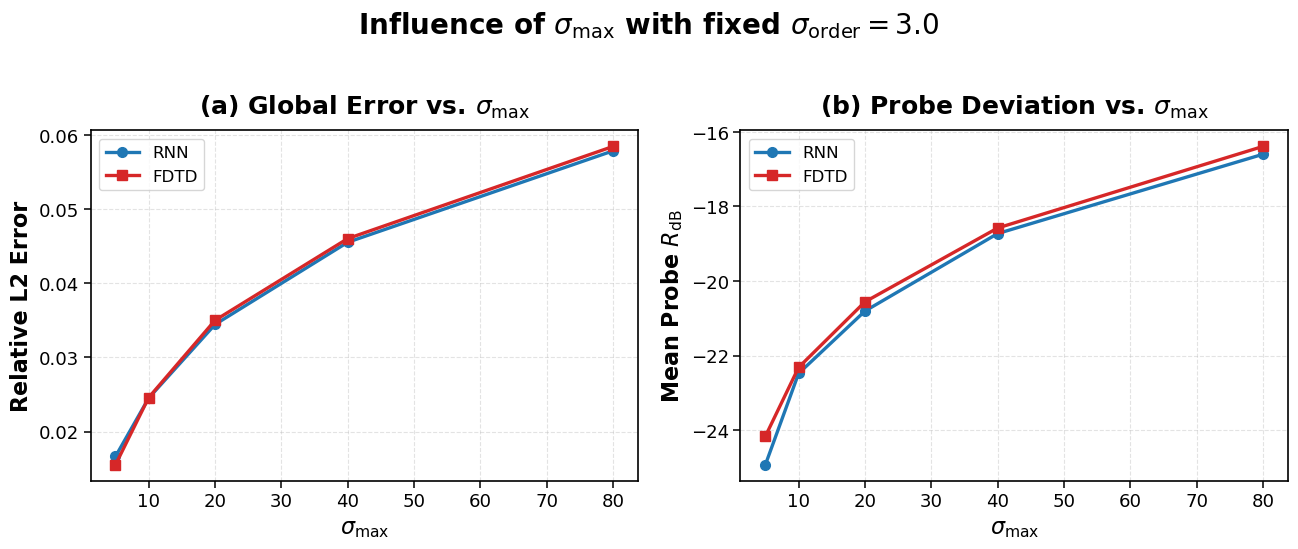

Saved: sigma_parameter_study_gpu_double/fig_sigma_order_study.png
Saved: sigma_parameter_study_gpu_double/fig_sigma_order_study.pdf


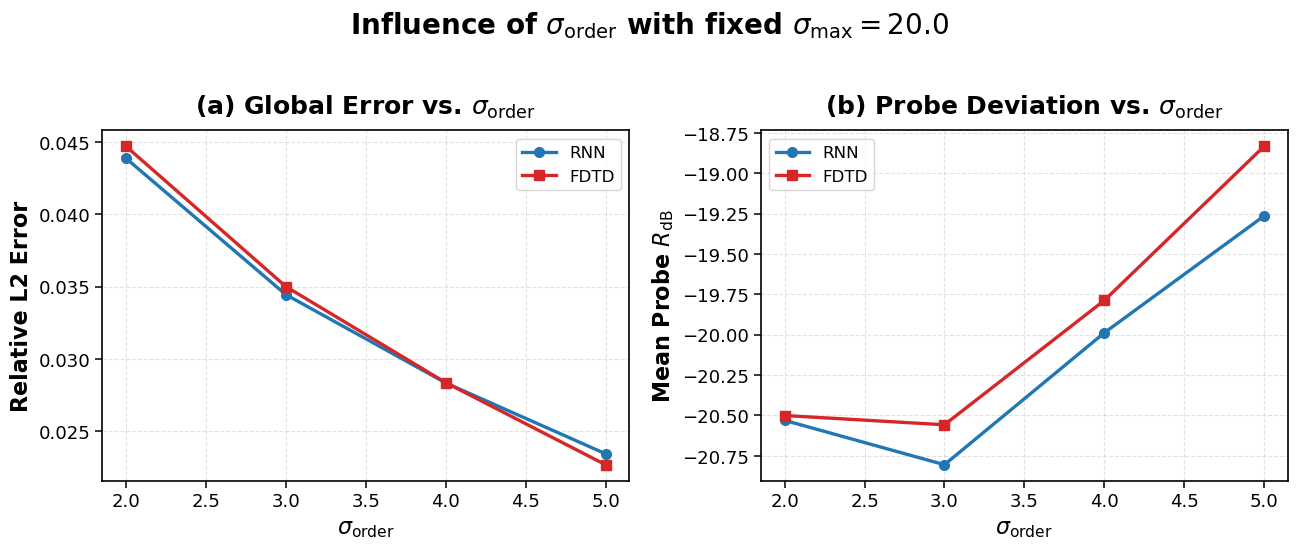


All done.
Results saved in: sigma_parameter_study_gpu_double


In [3]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import torch

# ============================================================
# Global plotting style
# ============================================================
mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12,
    "figure.titlesize": 20,
    "lines.linewidth": 2.2,
    "axes.linewidth": 1.2,
    "xtick.major.width": 1.1,
    "ytick.major.width": 1.1,
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

paper_colors = {
    "rnn": "#1f77b4",
    "fdtd": "#d62728",
    "gray": "#7f7f7f",
    "green": "#2ca02c",
    "purple": "#9467bd",
    "orange": "#ff7f0e",
}

def save_fig(fig, out_dir, name):
    png = os.path.join(out_dir, f"{name}.png")
    pdf = os.path.join(out_dir, f"{name}.pdf")
    fig.savefig(png)
    fig.savefig(pdf)
    print(f"Saved: {png}")
    print(f"Saved: {pdf}")

def style_axis(ax, grid_axis="y"):
    ax.grid(True, axis=grid_axis, linestyle="--", alpha=0.35)

# ============================================================
# Common settings
# ============================================================
output_dir = "sigma_parameter_study_gpu_double"
os.makedirs(output_dir, exist_ok=True)

# -----------------------------
# Physical parameters
# -----------------------------
c = 1.0
L = 5.0
T = 5.0
x_src = 2.5
freq = 1.0
omega = 2.0 * np.pi * freq
source_sigma = 0.1

probe_positions = [0.1, 0.2, 4.8, 4.9]

# -----------------------------
# Absorbing layer settings
# -----------------------------
USE_PML = True
pml_width = 1.5

# -----------------------------
# FDTD settings (fixed)
# -----------------------------
fdtd_dx = 1e-4
fdtd_dt = fdtd_dx / c

# -----------------------------
# RNN settings
# -----------------------------
initial_seed = 5
num_neuron = 3000
r_neuron = [5, 5]
N_pde = 30000
N_bnd = 20000
N_ini = 10000
p_pde = 1.0
p_bnd = 10.0
p_ini_u = 10.0
p_ini_v = 10.0
solve_block_size = 5000
predict_chunk_size_t = 20

device = torch.device("cuda:4" if torch.cuda.is_available() else "cpu")
dtype = torch.double

print(f"Using device: {device}")
print(f"Using dtype  : {dtype}")

# -----------------------------
# Parameter study plan
# -----------------------------
sigma_max_list = [5.0, 10.0, 20.0, 40.0, 80.0]
sigma_order_list = [2, 3, 4, 5]
fixed_sigma_max_for_order = 20.0
fixed_sigma_order_for_max = 3.0

# ============================================================
# Shared helpers
# ============================================================
def get_domain_bounds():
    return -pml_width, L + pml_width

x_left, x_right = get_domain_bounds()

def interpolate_trace_along_x(x_grid, u_xt, x_query):
    if x_query <= x_grid[0]:
        return u_xt[0, :].copy()
    if x_query >= x_grid[-1]:
        return u_xt[-1, :].copy()

    i1 = np.searchsorted(x_grid, x_query)
    i0 = i1 - 1
    x0 = x_grid[i0]
    x1 = x_grid[i1]
    alpha = (x_query - x0) / (x1 - x0)
    return (1.0 - alpha) * u_xt[i0, :] + alpha * u_xt[i1, :]

def interpolate_trace_in_time(t_old, trace_old, t_new):
    return np.interp(t_new, t_old, trace_old)

def compute_probe_metrics(x_num, t_num, u_num_xt, x_ref, t_ref, u_ref_xt, probe_positions, eps=1e-15):
    results = []

    for xpos in probe_positions:
        trace_num = interpolate_trace_along_x(x_num, u_num_xt, xpos)
        trace_ref_raw = interpolate_trace_along_x(x_ref, u_ref_xt, xpos)

        if len(t_ref) != len(t_num) or not np.allclose(t_ref, t_num):
            trace_ref = interpolate_trace_in_time(t_ref, trace_ref_raw, t_num)
        else:
            trace_ref = trace_ref_raw

        diff_trace = trace_num - trace_ref
        numerator = np.max(np.abs(diff_trace))
        denominator = np.max(np.abs(trace_ref))

        if denominator < eps:
            R = np.nan
            R_dB = np.nan
        else:
            R = numerator / denominator
            R_dB = 20.0 * np.log10(max(R, eps))

        results.append({
            "x": xpos,
            "R_linear": R,
            "R_dB": R_dB,
            "trace_num": trace_num,
            "trace_ref": trace_ref,
            "trace_diff": diff_trace
        })

    return results

def compute_worst_metric_in_region(x_num, t_num, u_num_xt, x_ref, t_ref, u_ref_xt,
                                   x_region_min, x_region_max, n_probe=50, eps=1e-15):
    probe_x = np.linspace(x_region_min, x_region_max, n_probe)
    results = compute_probe_metrics(
        x_num, t_num, u_num_xt,
        x_ref, t_ref, u_ref_xt,
        probe_x, eps=eps
    )
    valid = [r for r in results if np.isfinite(r["R_linear"])]
    if len(valid) == 0:
        return None
    return max(valid, key=lambda d: d["R_linear"])

def summarize_case(method_name, sigma_max, sigma_order, x_num, t_num, u_num_xt, x_ref, t_ref, u_ref_xt):
    rel_l2 = np.linalg.norm(u_num_xt - u_ref_xt) / max(np.linalg.norm(u_ref_xt), 1e-15)

    probe_results = compute_probe_metrics(
        x_num, t_num, u_num_xt,
        x_ref, t_ref, u_ref_xt,
        probe_positions
    )

    left_worst = compute_worst_metric_in_region(
        x_num, t_num, u_num_xt,
        x_ref, t_ref, u_ref_xt,
        0.0, 0.5, n_probe=50
    )
    right_worst = compute_worst_metric_in_region(
        x_num, t_num, u_num_xt,
        x_ref, t_ref, u_ref_xt,
        4.5, 5.0, n_probe=50
    )

    mean_probe_db = np.nanmean([item["R_dB"] for item in probe_results])

    row = {
        "method": method_name,
        "sigma_max": sigma_max,
        "sigma_order": sigma_order,
        "rel_l2": rel_l2,
        "probe_x0.1_dB": probe_results[0]["R_dB"],
        "probe_x0.2_dB": probe_results[1]["R_dB"],
        "probe_x4.8_dB": probe_results[2]["R_dB"],
        "probe_x4.9_dB": probe_results[3]["R_dB"],
        "mean_probe_dB": mean_probe_db,
        "left_worst_dB": np.nan if left_worst is None else left_worst["R_dB"],
        "right_worst_dB": np.nan if right_worst is None else right_worst["R_dB"],
    }
    return row, probe_results

# ============================================================
# Reference solution
# ============================================================
reference_file = "1d_fdtd_ref_5e-5.npy"
u_ref_xt = np.load(reference_file).T.astype(np.float64)

# 直接按文件 shape 构造参考网格，避免你之前那种 shape / 网格不一致的问题
x_ref = np.linspace(0.0, L, u_ref_xt.shape[0])
t_ref = np.linspace(0.0, T, u_ref_xt.shape[1])

print(f"Loaded reference file: {reference_file}")
print(f"Reference shape = {u_ref_xt.shape}")

# ============================================================
# GPU FDTD damping solver (double precision)
# ============================================================
def run_fdtd_case_gpu(sigma_max, sigma_order):
    dx = fdtd_dx
    dt = fdtd_dt

    n_pml = int(round(pml_width / dx))
    actual_pml_width = n_pml * dx

    nx_total = int(round(L / dx)) + 1
    nx = nx_total + 2 * n_pml
    nt = int(round(T / dt)) + 1

    x = np.arange(nx, dtype=np.float64) * dx - actual_pml_width
    x_main = np.linspace(0.0, L, nx_total, dtype=np.float64)
    t = np.linspace(0.0, T, nt, dtype=np.float64)

    # 映射到参考解保存网格
    save_t_idx = np.array([np.argmin(np.abs(t - tt)) for tt in t_ref], dtype=np.int64)
    save_x_idx_main_local = np.array([np.argmin(np.abs(x_main - xx)) for xx in x_ref], dtype=np.int64)
    save_x_idx_main = save_x_idx_main_local + n_pml

    probe_positions_np = np.array(probe_positions, dtype=np.float64)
    probe_idx_main_local = np.array([np.argmin(np.abs(x_main - xp)) for xp in probe_positions_np], dtype=np.int64)
    probe_idx_main = probe_idx_main_local + n_pml

    # 搬到 GPU
    x_t = torch.tensor(x, device=device, dtype=dtype)
    gaussian_source_weights = torch.exp(-((x_t - x_src) ** 2) / (2.0 * source_sigma ** 2))

    sigma = torch.zeros(nx, device=device, dtype=dtype)
    left_mask = x_t < 0.0
    right_mask = x_t > L
    sigma[left_mask] = sigma_max * ((0.0 - x_t[left_mask]) / pml_width) ** sigma_order
    sigma[right_mask] = sigma_max * ((x_t[right_mask] - L) / pml_width) ** sigma_order

    denom = 1.0 + sigma * dt / 2.0
    c1 = 2.0 / denom
    c2 = (1.0 - sigma * dt / 2.0) / denom
    c3 = ((c * dt / dx) ** 2) / denom
    c_src = (dt ** 2) / denom

    save_t_idx_t = torch.tensor(save_t_idx, device=device, dtype=torch.long)
    save_x_idx_main_t = torch.tensor(save_x_idx_main, device=device, dtype=torch.long)
    probe_idx_main_t = torch.tensor(probe_idx_main, device=device, dtype=torch.long)

    Ex = torch.zeros(nx, device=device, dtype=dtype)
    Ex_prev = torch.zeros(nx, device=device, dtype=dtype)
    Ex_next = torch.zeros(nx, device=device, dtype=dtype)

    Ex_save_main = np.zeros((len(t_ref), len(x_ref)), dtype=np.float64)
    probe_traces = np.zeros((len(probe_positions), nt), dtype=np.float64)

    save_counter = 0
    two_pi_freq_dt = 2.0 * np.pi * freq * dt

    if device.type == "cuda":
        torch.cuda.synchronize()

    start = time.perf_counter()

    for n in range(nt):
        Ex_next[1:-1] = (
            c1[1:-1] * Ex[1:-1]
            - c2[1:-1] * Ex_prev[1:-1]
            + c3[1:-1] * (Ex[2:] - 2.0 * Ex[1:-1] + Ex[:-2])
        )

        amplitude = 0.5 if n < 1 else 1.0
        source_phase = amplitude * np.cos(two_pi_freq_dt * n)
        Ex_next += gaussian_source_weights * source_phase * c_src

        Ex_next[0] = 0.0
        Ex_next[-1] = 0.0

        # 保存探针
        probe_traces[:, n] = Ex.index_select(0, probe_idx_main_t).detach().cpu().numpy()

        # 保存主域抽样
        if save_counter < len(t_ref) and n == save_t_idx[save_counter]:
            Ex_save_main[save_counter] = Ex.index_select(0, save_x_idx_main_t).detach().cpu().numpy()
            save_counter += 1

        Ex_prev, Ex, Ex_next = Ex, Ex_next, Ex_prev
        Ex_next.zero_()

    if device.type == "cuda":
        torch.cuda.synchronize()

    elapsed = time.perf_counter() - start
    print(f"FDTD case done: sigma_max={sigma_max}, sigma_order={sigma_order}, time={elapsed:.3f}s")

    u_fdtd_main_xt = Ex_save_main.T  # shape = (Nx_ref, Nt_ref)
    return x_ref.copy(), t_ref.copy(), u_fdtd_main_xt

# ============================================================
# RNN damping solver
# ============================================================
def sigma_x_torch(X, sigma_max, sigma_order):
    X = X.to(dtype)
    sig = torch.zeros_like(X, dtype=dtype, device=X.device)

    if not USE_PML:
        return sig

    left_mask = X < 0.0
    if left_mask.any():
        sig[left_mask] = sigma_max * ((0.0 - X[left_mask]) / pml_width) ** sigma_order

    right_mask = X > L
    if right_mask.any():
        sig[right_mask] = sigma_max * ((X[right_mask] - L) / pml_width) ** sigma_order

    return sig

def generate_points_rnn():
    N_uniform = N_pde
    N_gaussian = N_pde - N_uniform

    xi_uniform = x_left + (x_right - x_left) * torch.rand(
        N_uniform, 1, device=device, dtype=dtype
    )
    ti_uniform = T * torch.rand(
        N_uniform, 1, device=device, dtype=dtype
    )

    xi_gaussian = torch.normal(
        mean=x_src,
        std=0.1,
        size=(N_gaussian, 1),
        device=device
    ).to(dtype).clamp(x_left, x_right)

    ti_gaussian = T * torch.rand(
        N_gaussian, 1, device=device, dtype=dtype
    )

    xi = torch.cat((xi_uniform, xi_gaussian), dim=0)
    ti = torch.cat((ti_uniform, ti_gaussian), dim=0)
    pti = torch.cat((xi, ti), dim=1).to(dtype)

    tb = T * torch.rand(N_bnd, 1, device=device, dtype=dtype)
    ptb_left = torch.cat((torch.full_like(tb, x_left), tb), dim=1)
    ptb_right = torch.cat((torch.full_like(tb, x_right), tb), dim=1)
    ptb = torch.cat((ptb_left, ptb_right), dim=0).to(dtype)

    xi_ini = x_left + (x_right - x_left) * torch.rand(
        N_ini, 1, device=device, dtype=dtype
    )
    ti_ini = torch.zeros(N_ini, 1, device=device, dtype=dtype)
    pt_ini = torch.cat((xi_ini, ti_ini), dim=1).to(dtype)

    return pti, ptb, pt_ini

def atv(x):
    return torch.tanh(x)

def diff1_atv(x):
    return 1.0 - torch.tanh(x) ** 2

def diff2_atv(x):
    th = torch.tanh(x)
    return 2.0 * th * (th**2 - 1.0)

def feature_value(W, b, points):
    X = points[:, 0:1]
    Tt = points[:, 1:2]
    W_x = W[0:1, :]
    W_t = W[1:2, :]
    Z = X @ W_x + Tt @ W_t + b
    return atv(Z)

def feature_t(W, b, points):
    X = points[:, 0:1]
    Tt = points[:, 1:2]
    W_x = W[0:1, :]
    W_t = W[1:2, :]
    Z = X @ W_x + Tt @ W_t + b
    return W_t * diff1_atv(Z)

def feature_xx(W, b, points):
    X = points[:, 0:1]
    Tt = points[:, 1:2]
    W_x = W[0:1, :]
    W_t = W[1:2, :]
    Z = X @ W_x + Tt @ W_t + b
    return (W_x ** 2) * diff2_atv(Z)

def feature_tt(W, b, points):
    X = points[:, 0:1]
    Tt = points[:, 1:2]
    W_x = W[0:1, :]
    W_t = W[1:2, :]
    Z = X @ W_x + Tt @ W_t + b
    return (W_t ** 2) * diff2_atv(Z)

def source_term_rnn(points):
    X = points[:, 0:1]
    Tt = points[:, 1:2]
    return torch.cos(2.0 * np.pi * freq * Tt) * torch.exp(-((X - x_src) ** 2) / 0.02)

def u0(x):
    return torch.zeros_like(x)

def v0(x):
    return torch.zeros_like(x)

def wave_equation_residual_rnn(W, b, points, sigma_max, sigma_order):
    phi_tt = feature_tt(W, b, points)
    phi_xx = feature_xx(W, b, points)
    X = points[:, 0:1]
    sig = sigma_x_torch(X, sigma_max, sigma_order)
    phi_t = feature_t(W, b, points)
    return phi_tt + sig * phi_t - (c ** 2) * phi_xx

@torch.no_grad()
def solve_blockwise_normal_equation_rnn(W, b, pti, ptb, pt_ini, sigma_max, sigma_order, ridge=1e-6):
    M = W.shape[1]
    ATA = torch.zeros((M, M), dtype=dtype, device=device)
    ATF = torch.zeros((M, 1), dtype=dtype, device=device)

    n_pde_total = pti.shape[0]

    for i0 in range(0, n_pde_total, solve_block_size):
        i1 = min(i0 + solve_block_size, n_pde_total)
        pti_block = pti[i0:i1]

        A_pde_block = p_pde * wave_equation_residual_rnn(W, b, pti_block, sigma_max, sigma_order)
        F_pde_block = p_pde * source_term_rnn(pti_block).to(dtype)

        ATA += A_pde_block.T @ A_pde_block
        ATF += A_pde_block.T @ F_pde_block

        del pti_block, A_pde_block, F_pde_block
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    A_bnd = p_bnd * feature_value(W, b, ptb)
    F_bnd = torch.zeros((ptb.shape[0], 1), dtype=dtype, device=device)
    ATA += A_bnd.T @ A_bnd
    ATF += A_bnd.T @ F_bnd
    del A_bnd, F_bnd
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    A_ini_u = p_ini_u * feature_value(W, b, pt_ini)
    F_ini_u = p_ini_u * u0(pt_ini[:, 0:1]).to(dtype)
    ATA += A_ini_u.T @ A_ini_u
    ATF += A_ini_u.T @ F_ini_u
    del A_ini_u, F_ini_u
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    A_ini_v = p_ini_v * feature_t(W, b, pt_ini)
    F_ini_v = p_ini_v * v0(pt_ini[:, 0:1]).to(dtype)
    ATA += A_ini_v.T @ A_ini_v
    ATF += A_ini_v.T @ F_ini_v
    del A_ini_v, F_ini_v
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    ATA += ridge * torch.eye(M, dtype=dtype, device=device)
    Ur = torch.linalg.solve(ATA, ATF)
    return Ur

@torch.no_grad()
def predict_main_grid_in_batches_rnn(x_test, t_test, W, b, Ur):
    Nx = x_test.shape[0]
    Nt = t_test.shape[0]
    u_pred_np = np.zeros((Nx, Nt), dtype=np.float64)

    W_x = W[0:1, :]
    W_t = W[1:2, :]
    X_part = x_test.unsqueeze(1) @ W_x

    for j0 in range(0, Nt, predict_chunk_size_t):
        j1 = min(j0 + predict_chunk_size_t, Nt)
        t_chunk = t_test[j0:j1]

        T_part = t_chunk.unsqueeze(1) @ W_t
        Z_chunk = X_part[:, None, :] + T_part[None, :, :] + b[None, :, :]
        phi_chunk = atv(Z_chunk)

        phi_2d = phi_chunk.reshape(-1, phi_chunk.shape[-1])
        u_chunk = (phi_2d @ Ur).reshape(Nx, j1 - j0)
        u_pred_np[:, j0:j1] = u_chunk.detach().cpu().numpy()

        del t_chunk, T_part, Z_chunk, phi_chunk, phi_2d, u_chunk
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return u_pred_np

def run_rnn_case(sigma_max, sigma_order):
    torch.manual_seed(initial_seed)
    np.random.seed(initial_seed)

    W1 = torch.tensor(
        np.random.uniform(-r_neuron[0], r_neuron[0], (1, num_neuron)),
        dtype=dtype,
        device=device
    )
    W2 = torch.tensor(
        np.random.uniform(-r_neuron[1], r_neuron[1], (1, num_neuron)),
        dtype=dtype,
        device=device
    )
    W = torch.cat((W1, W2), dim=0)

    b1 = torch.tensor(
        np.random.uniform(x_left, x_right, (1, num_neuron)),
        dtype=dtype,
        device=device
    )
    b2 = torch.tensor(
        np.random.uniform(0.0, T, (1, num_neuron)),
        dtype=dtype,
        device=device
    )
    b_shift = torch.cat((b1, b2), dim=0)
    b = -torch.sum(b_shift * W, dim=0, keepdim=True)

    pti, ptb, pt_ini = generate_points_rnn()

    start = time.perf_counter()
    Ur = solve_blockwise_normal_equation_rnn(
        W=W, b=b,
        pti=pti, ptb=ptb, pt_ini=pt_ini,
        sigma_max=sigma_max, sigma_order=sigma_order,
        ridge=1e-6
    )

    x_test_main = torch.tensor(x_ref, device=device, dtype=dtype)
    t_test_main = torch.tensor(t_ref, device=device, dtype=dtype)

    u_pred_main = predict_main_grid_in_batches_rnn(
        x_test=x_test_main,
        t_test=t_test_main,
        W=W,
        b=b,
        Ur=Ur
    )
    elapsed = time.perf_counter() - start

    print(f"RNN case done: sigma_max={sigma_max}, sigma_order={sigma_order}, time={elapsed:.3f}s")
    return x_ref.copy(), t_ref.copy(), u_pred_main

# ============================================================
# Parameter study
# ============================================================
all_rows = []

# -----------------------------
# Study 1: sigma_max
# -----------------------------
print("\n" + "=" * 80)
print("Study 1: scan sigma_max with sigma_order fixed")
print("=" * 80)

for smax in sigma_max_list:
    x_fdtd, t_fdtd, u_fdtd = run_fdtd_case_gpu(sigma_max=smax, sigma_order=fixed_sigma_order_for_max)
    row_fdtd, _ = summarize_case(
        method_name="FDTD",
        sigma_max=smax,
        sigma_order=fixed_sigma_order_for_max,
        x_num=x_fdtd, t_num=t_fdtd, u_num_xt=u_fdtd,
        x_ref=x_ref, t_ref=t_ref, u_ref_xt=u_ref_xt
    )
    row_fdtd["study"] = "sigma_max"
    all_rows.append(row_fdtd)

    x_rnn, t_rnn, u_rnn = run_rnn_case(sigma_max=smax, sigma_order=fixed_sigma_order_for_max)
    row_rnn, _ = summarize_case(
        method_name="RNN",
        sigma_max=smax,
        sigma_order=fixed_sigma_order_for_max,
        x_num=x_rnn, t_num=t_rnn, u_num_xt=u_rnn,
        x_ref=x_ref, t_ref=t_ref, u_ref_xt=u_ref_xt
    )
    row_rnn["study"] = "sigma_max"
    all_rows.append(row_rnn)

# -----------------------------
# Study 2: sigma_order
# -----------------------------
print("\n" + "=" * 80)
print("Study 2: scan sigma_order with sigma_max fixed")
print("=" * 80)

for sord in sigma_order_list:
    x_fdtd, t_fdtd, u_fdtd = run_fdtd_case_gpu(sigma_max=fixed_sigma_max_for_order, sigma_order=sord)
    row_fdtd, _ = summarize_case(
        method_name="FDTD",
        sigma_max=fixed_sigma_max_for_order,
        sigma_order=sord,
        x_num=x_fdtd, t_num=t_fdtd, u_num_xt=u_fdtd,
        x_ref=x_ref, t_ref=t_ref, u_ref_xt=u_ref_xt
    )
    row_fdtd["study"] = "sigma_order"
    all_rows.append(row_fdtd)

    x_rnn, t_rnn, u_rnn = run_rnn_case(sigma_max=fixed_sigma_max_for_order, sigma_order=sord)
    row_rnn, _ = summarize_case(
        method_name="RNN",
        sigma_max=fixed_sigma_max_for_order,
        sigma_order=sord,
        x_num=x_rnn, t_num=t_rnn, u_num_xt=u_rnn,
        x_ref=x_ref, t_ref=t_ref, u_ref_xt=u_ref_xt
    )
    row_rnn["study"] = "sigma_order"
    all_rows.append(row_rnn)

# ============================================================
# Unified paper-style plotting / table export
# ============================================================
df = pd.DataFrame(all_rows)
df = df.sort_values(by=["study", "sigma_max", "sigma_order", "method"]).reset_index(drop=True)

csv_path = os.path.join(output_dir, "sigma_parameter_study_table.csv")
df.to_csv(csv_path, index=False)
print(f"\nSaved table: {csv_path}")

summary_rows = []

df_max = df[df["study"] == "sigma_max"].copy()
for smax in sigma_max_list:
    sub = df_max[df_max["sigma_max"] == smax]
    row = {"Study": "sigma_max", "Parameter": smax}

    for method in ["RNN", "FDTD"]:
        sm = sub[sub["method"] == method].iloc[0]
        row[f"{method} RelL2"] = sm["rel_l2"]
        row[f"{method} MeanProbe_dB"] = sm["mean_probe_dB"]
        row[f"{method} LeftWorst_dB"] = sm["left_worst_dB"]
        row[f"{method} RightWorst_dB"] = sm["right_worst_dB"]

    summary_rows.append(row)

df_order = df[df["study"] == "sigma_order"].copy()
for sord in sigma_order_list:
    sub = df_order[df_order["sigma_order"] == sord]
    row = {"Study": "sigma_order", "Parameter": sord}

    for method in ["RNN", "FDTD"]:
        sm = sub[sub["method"] == method].iloc[0]
        row[f"{method} RelL2"] = sm["rel_l2"]
        row[f"{method} MeanProbe_dB"] = sm["mean_probe_dB"]
        row[f"{method} LeftWorst_dB"] = sm["left_worst_dB"]
        row[f"{method} RightWorst_dB"] = sm["right_worst_dB"]

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_csv_path = os.path.join(output_dir, "sigma_parameter_study_summary_table.csv")
summary_df.to_csv(summary_csv_path, index=False)
print(f"Saved summary table: {summary_csv_path}")

print("\n===== Summary Table =====")
print(summary_df.to_string(index=False))

# ============================================================
# Figure 1: sigma_max scan
# ============================================================
fig, axs = plt.subplots(1, 2, figsize=(13.2, 5.4))

for method, color, marker in [("RNN", paper_colors["rnn"], "o"), ("FDTD", paper_colors["fdtd"], "s")]:
    sub = df_max[df_max["method"] == method].sort_values("sigma_max")

    axs[0].plot(
        sub["sigma_max"], sub["rel_l2"],
        marker=marker, color=color, linewidth=2.4, markersize=7, label=method
    )
    axs[1].plot(
        sub["sigma_max"], sub["mean_probe_dB"],
        marker=marker, color=color, linewidth=2.4, markersize=7, label=method
    )

axs[0].set_xlabel(r"$\sigma_{\max}$", fontweight="bold")
axs[0].set_ylabel("Relative L2 Error", fontweight="bold")
axs[0].set_title(r"(a) Global Error vs. $\sigma_{\max}$", fontweight="bold", pad=12)
style_axis(axs[0], grid_axis="both")
axs[0].legend(frameon=True)

axs[1].set_xlabel(r"$\sigma_{\max}$", fontweight="bold")
axs[1].set_ylabel(r"Mean Probe $R_{\mathrm{dB}}$", fontweight="bold")
axs[1].set_title(r"(b) Probe Deviation vs. $\sigma_{\max}$", fontweight="bold", pad=12)
style_axis(axs[1], grid_axis="both")
axs[1].legend(frameon=True)

fig.suptitle(
    rf"Influence of $\sigma_{{\max}}$ with fixed $\sigma_{{\mathrm{{order}}}}={fixed_sigma_order_for_max}$",
    fontweight="bold",
    y=1.02
)

fig.tight_layout()
save_fig(fig, output_dir, "fig_sigma_max_study")
plt.show()

# ============================================================
# Figure 2: sigma_order scan
# ============================================================
fig, axs = plt.subplots(1, 2, figsize=(13.2, 5.4))

for method, color, marker in [("RNN", paper_colors["rnn"], "o"), ("FDTD", paper_colors["fdtd"], "s")]:
    sub = df_order[df_order["method"] == method].sort_values("sigma_order")

    axs[0].plot(
        sub["sigma_order"], sub["rel_l2"],
        marker=marker, color=color, linewidth=2.4, markersize=7, label=method
    )
    axs[1].plot(
        sub["sigma_order"], sub["mean_probe_dB"],
        marker=marker, color=color, linewidth=2.4, markersize=7, label=method
    )

axs[0].set_xlabel(r"$\sigma_{\mathrm{order}}$", fontweight="bold")
axs[0].set_ylabel("Relative L2 Error", fontweight="bold")
axs[0].set_title(r"(a) Global Error vs. $\sigma_{\mathrm{order}}$", fontweight="bold", pad=12)
style_axis(axs[0], grid_axis="both")
axs[0].legend(frameon=True)

axs[1].set_xlabel(r"$\sigma_{\mathrm{order}}$", fontweight="bold")
axs[1].set_ylabel(r"Mean Probe $R_{\mathrm{dB}}$", fontweight="bold")
axs[1].set_title(r"(b) Probe Deviation vs. $\sigma_{\mathrm{order}}$", fontweight="bold", pad=12)
style_axis(axs[1], grid_axis="both")
axs[1].legend(frameon=True)

fig.suptitle(
    rf"Influence of $\sigma_{{\mathrm{{order}}}}$ with fixed $\sigma_{{\max}}={fixed_sigma_max_for_order}$",
    fontweight="bold",
    y=1.02
)

fig.tight_layout()
save_fig(fig, output_dir, "fig_sigma_order_study")
plt.show()

print("\nAll done.")
print(f"Results saved in: {output_dir}")